# Radar Pipeline Walkthrough  
## Reproducible Trade-offs, Statistical Contracts, and System-Level Reasoning

**What this notebook demonstrates**
- How to evaluate radar performance as a coupled system with explicit trade-offs.
- How analytic models are validated (and sometimes disproven) using Monte Carlo simulation.
- How false alarm *rates* emerge from simple false alarm *probabilities* once geometry and timing are included.

**What this notebook does NOT demonstrate**
- Low-level DSP implementation details (matched filtering, FFT internals, etc.).
- Real-time or hardware-specific radar constraints.
- Tracking, data association, or mission-level simulation.

**What this notebook generates**
- Deterministic and Monte Carlo radar performance results under `results/`
- Trade-off plots: Pd vs SNR, integration vs FAR, detector robustness
- Reproducibility artifacts: `metrics.json`, `manifest.json`, normalized configs, and comparison CSVs

In [1]:
%matplotlib inline

import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["savefig.dpi"] = 160

print("[OK] Matplotlib inline backend configured")


[OK] Matplotlib inline backend configured


## 1. Environment & Reproducibility

This notebook is designed to be **fully reproducible**.

Key guarantees:
- All executions use a **fixed random seed**.
- All generated artifacts are written under the `results/` directory.
- The notebook is safe to re-run end-to-end:
  - Existing `results/` can be deleted and regenerated deterministically.

This mirrors how the repository is validated in Continuous Integration (CI):
the same commands must produce the same outputs within statistical tolerance.

## 2. Setup (Helpers and Conventions)

In the next step, we will define minimal helper utilities to:
- Run shell commands from the notebook.
- Load and inspect JSON artifacts.
- Perform simple structural sanity checks on outputs.

These helpers are **not part of the radar model**.
They exist only to make the notebook readable and auditable.

## 3. Happy Path: One Deterministic Model-Based Case

We start with the simplest meaningful execution:

- Run **one deterministic, analytic (model_based)** radar case.
- No Monte Carlo yet.
- No sweeps.
- No plots required to understand correctness.

**Expected checkpoints**
- A new directory appears under `results/cases/`
- The directory contains:
  - `metrics.json`
  - `case_manifest.json`
- The execution engine is explicitly declared as `model_based`.

This establishes the baseline:  
*"Can the system execute one clean, contract-valid run?"*

## 4. Trade-off Demonstrations (System-Level Evidence)

Next, we run the repository’s **canonical trade-off demos**.

These are not toy examples; they encode expected radar behavior:

- **Integration vs FAR**
  - Increasing coherent integration improves SNR and Pd
  - But increases the number of decisions → FAR inflation

- **Antenna gain vs coverage**
  - Higher gain improves local SNR
  - But reduces volumetric coverage due to scan loss

- **Detector vs environment**
  - CA-CFAR vs OS-CFAR under homogeneous and heterogeneous clutter

The goal is not “good performance”  
The goal is **visible trade-offs**.

## 5. Failures by Design: CFAR in Heterogeneous Clutter

**CA-CFAR (Cell-Averaging CFAR)**  
A detector that estimates noise power by averaging neighboring reference cells.

**OS-CFAR (Order-Statistic CFAR)**  
A detector that estimates noise power using a ranked statistic, improving robustness in non-homogeneous clutter.

**What we expect to see**
- In heterogeneous clutter:
  - CA-CFAR does NOT maintain the requested Pfa
  - OS-CFAR performs better, but with its own biases

This behavior is intentional and preserved.
Failure here is **signal**, not a bug.

## 6. Model vs Monte Carlo Gate (CI Meaning)

Here, **CI** means **Continuous Integration**, not Confidence Interval.

In CI, the repository enforces a gate:

- Run an analytic Pd model.
- Run a Monte Carlo simulation of the same scenario.
- Measure the maximum absolute difference in Pd.

**Gate condition**
- Metric: `pd_abs_err_max`
- Threshold: explicitly defined in CI
- If the discrepancy exceeds the threshold → CI fails.

This ensures:
- Models are not silently drifting away from empirical reality.

## 7. Technical Conclusions and Scope of Validity

This notebook demonstrates a reproducible framework for evaluating radar
performance at the system level, with explicit treatment of statistical
assumptions, trade-offs, and limits of validity.

Key conclusions supported by the executed cases include:

- Radar performance metrics (Pd, Pfa, FAR, coverage) are inherently coupled and
  must be evaluated jointly rather than in isolation.
- A fixed probability of false alarm (Pfa) does not characterize operational
  behavior without explicit accounting of decision rates and geometry; system-level
  false alarm rate (FAR) is the relevant metric.
- Analytic detection models provide useful predictions only within their declared
  assumptions and must be validated empirically using Monte Carlo simulation.
- Common detectors such as CA-CFAR do not preserve constant false alarm behavior
  under heterogeneous clutter conditions; this failure mode is intentional,
  measured, and documented.
- Discrepancies between analytic models and Monte Carlo results are treated as
  first-class outputs and are gated in continuous integration to prevent silent
  model drift.

All results presented here are valid only within the declared statistical,
environmental, and operational assumptions recorded in each run’s manifest.
Outside those regimes, correctness is explicitly not guaranteed.

## 1. Environment & Reproducibility

This notebook is designed to be **fully reproducible** and safe to execute
end-to-end without manual intervention.

Before running any radar cases or generating artifacts, we explicitly verify
that the execution environment is compatible with the repository.

The goals of this step are:

- Ensure the notebook is executed from within a valid repository checkout.
- Record basic execution metadata (Python version, platform).
- Fail fast if required internal modules cannot be imported.

This mirrors how the repository is validated in **Continuous Integration (CI)**:
the same environment checks must pass before any performance results are trusted.

No radar models are executed at this stage.
No artifacts are generated.

In [2]:
# 1. Environment & Reproducibility — repo-safe environment check 

from __future__ import annotations

from pathlib import Path
import platform
import sys

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for parent in [p] + list(p.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return p  # fallback: current dir

repo_root = find_repo_root(Path.cwd())

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

repo_name = repo_root.name

py_ver = f"{sys.version_info.major}.{sys.version_info.minor}"
plat = f"{platform.system()} ({platform.machine()})"

# Import checks (fail fast if environment is wrong)
import core.metrics.performance  # noqa: F401
import validation.sanity_checks  # noqa: F401

print(f"[OK] Repo: {repo_name}")
print(f"[OK] Python: {py_ver}")
print(f"[OK] Platform: {plat}")
print("[OK] Imports: core.metrics.performance, validation.sanity_checks")

[OK] Repo: radar_pipeline
[OK] Python: 3.12
[OK] Platform: Darwin (arm64)
[OK] Imports: core.metrics.performance, validation.sanity_checks


**Result interpretation**

The environment check completed successfully:

- The notebook is running inside a valid repository checkout.
- The Python interpreter and platform are explicitly identified.
- Core internal modules required for performance evaluation and validation
  are importable.

At this point, the execution environment is considered **repository-safe**.

Subsequent sections assume:
- Deterministic behavior under fixed random seeds.
- All generated artifacts will be written under `results/`.
- Re-running the notebook from a clean state will reproduce the same results
  within statistical tolerance.

## 2. Setup (Helpers and Conventions)

Before executing any radar cases, we define a small set of helper utilities
used throughout this notebook.

These helpers serve three purposes:

- Execute repository commands from the notebook with streamed output.
- Load and inspect JSON artifacts produced by runs and sweeps.
- Perform lightweight structural checks on generated outputs.

These utilities are intentionally minimal and explicit.
They are designed to support **readability, traceability, and auditability**.

Importantly:
- They are **not part of the radar performance model**.
- They do not modify detection logic, geometry, or statistics.
- They exist solely to make the notebook execution transparent.

In [3]:
# 2. Setup (Helpers and Conventions)

from __future__ import annotations

import json
import os
import shlex
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Dict, Any, Iterable, Tuple

REPO_ROOT = repo_root  # from Step 1
SEED = 123

def _rel(p: Path) -> str:
    try:
        return str(p.resolve().relative_to(REPO_ROOT.resolve()))
    except Exception:
        return p.name

def run_cmd(
    cmd: str | Iterable[str],
    *,
    cwd: Optional[Path] = None,
    env: Optional[Dict[str, str]] = None,
    check: bool = True,
) -> int:
    cwd = (cwd or REPO_ROOT).resolve()
    merged_env = os.environ.copy()
    if env:
        merged_env.update({k: str(v) for k, v in env.items()})

    argv = cmd if isinstance(cmd, (list, tuple)) else shlex.split(cmd)
    print(f"[RUN] {cmd if isinstance(cmd, str) else ' '.join(map(shlex.quote, argv))}")

    proc = subprocess.Popen(
        argv,
        cwd=str(cwd),
        env=merged_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        universal_newlines=True,
    )

    assert proc.stdout is not None
    for line in proc.stdout:
        print(line.rstrip())

    rc = proc.wait()
    if check and rc != 0:
        raise RuntimeError(f"Command failed (exit={rc}): {cmd}")
    return rc

def read_json(path: Path) -> Dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))

def newest_dir(parent: Path) -> Optional[Path]:
    if not parent.exists():
        return None
    dirs = [p for p in parent.iterdir() if p.is_dir()]
    if not dirs:
        return None
    return max(dirs, key=lambda p: p.stat().st_mtime)

@dataclass(frozen=True)
class CaseArtifacts:
    run_dir: Path
    metrics_json: Path
    manifest_json: Path

def find_latest_case_artifacts() -> CaseArtifacts:
    cases_root = REPO_ROOT / "results" / "cases"
    d = newest_dir(cases_root)
    if d is None:
        raise FileNotFoundError("No case directories found under results/cases/.")
    metrics_p = d / "metrics.json"
    manifest_p = d / "case_manifest.json"
    if not metrics_p.exists():
        raise FileNotFoundError(f"Missing {_rel(metrics_p)}")
    if not manifest_p.exists():
        raise FileNotFoundError(f"Missing {_rel(manifest_p)}")
    return CaseArtifacts(run_dir=d, metrics_json=metrics_p, manifest_json=manifest_p)

print("[OK] Notebook helpers initialized")
print(f"[OK] Reproducibility: fixed random seed = {SEED}")
print("[OK] Outputs will be written under: results/")

CASE_YAML = "configs/cases/demo_pd_noise.yaml"
ENGINE = "model_based"
NOTEBOOK_CASES_ROOT = REPO_ROOT / "results" / "notebook_cases"
env = os.environ.copy()
env.setdefault("PYTHONPATH", str(REPO_ROOT))

print(f"[OK] CASE_YAML={CASE_YAML}")
print(f"[OK] ENGINE={ENGINE}")
print(f"[OK] NOTEBOOK_CASES_ROOT={_rel(NOTEBOOK_CASES_ROOT)}")


[OK] Notebook helpers initialized
[OK] Reproducibility: fixed random seed = 123
[OK] Outputs will be written under: results/
[OK] CASE_YAML=configs/cases/demo_pd_noise.yaml
[OK] ENGINE=model_based
[OK] NOTEBOOK_CASES_ROOT=results/notebook_cases


**Result interpretation**

The helper layer has been initialized successfully:

- A fixed random seed is declared for reproducibility.
- All generated artifacts will be written under the `results/` directory.
- Utility functions for command execution and artifact inspection are available.

From this point forward, all notebook sections rely on these helpers
for execution and inspection, but **no radar logic is embedded here**.

The next section begins the first end-to-end execution of a radar case,
using these helpers purely as an execution and inspection interface.

## 3. Happy Path: One Deterministic Model-Based Case

We begin with the simplest meaningful execution of the radar pipeline.

This step answers a single, fundamental question:

> *Can the system execute one clean, contract-valid run using the analytic
(model-based) engine?*

At this stage:
- Only one deterministic case is executed.
- No Monte Carlo simulation is involved.
- No parameter sweeps are performed.
- No plots are required to assess correctness.

The goal is to establish a baseline:
a successful, reproducible run that produces the expected artifacts under
declared assumptions.

In [4]:
import shutil

shutil.rmtree(NOTEBOOK_CASES_ROOT, ignore_errors=True)

cmd = [
    "make",
    "case",
    f"CASE={CASE_YAML}",
    f"ENGINE={ENGINE}",
    f"SEED={SEED}",
    f"OUT={NOTEBOOK_CASES_ROOT.relative_to(REPO_ROOT)}",
    "REPORT=0",
]

run_cmd(cmd, cwd=REPO_ROOT, env=env)

model_cases = sorted(
    [p for p in NOTEBOOK_CASES_ROOT.iterdir() if p.is_dir() and "model_based" in p.name],
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)

if not model_cases:
    raise RuntimeError(f"No model_based case found under {_rel(NOTEBOOK_CASES_ROOT)}")

NOTEBOOK_CASE_DIR = model_cases[0]
NOTEBOOK_METRICS_JSON = NOTEBOOK_CASE_DIR / "metrics.json"
NOTEBOOK_MANIFEST_JSON = NOTEBOOK_CASE_DIR / "manifest.json"
NOTEBOOK_CASE_MANIFEST_JSON = NOTEBOOK_CASE_DIR / "case_manifest.json"

for required in [NOTEBOOK_METRICS_JSON, NOTEBOOK_MANIFEST_JSON, NOTEBOOK_CASE_MANIFEST_JSON]:
    if not required.exists():
        raise FileNotFoundError(f"Missing expected artifact: {_rel(required)}")

print("[OK] Model-based case completed successfully")
print(f"[OK] NOTEBOOK_CASE_DIR={_rel(NOTEBOOK_CASE_DIR)}")


[RUN] make case CASE=configs/cases/demo_pd_noise.yaml ENGINE=model_based SEED=123 OUT=results/notebook_cases REPORT=0
[OK] Case complete: ${PROJECT_ROOT}/results/notebook_cases/demo_pd_noise__model_based__seed123__cfga7a0ba17
[OK] Model-based case completed successfully
[OK] NOTEBOOK_CASE_DIR=results/notebook_cases/demo_pd_noise__model_based__seed123__cfga7a0ba17


**Execution result**

The model-based case completed successfully.

At this point, we have verified that:
- The analytic execution engine runs end-to-end.
- The repository can generate a deterministic case without errors.
- Outputs are written under the expected `results/cases/` directory.

In the next step, we inspect the generated artifacts to confirm that
the run produced the expected files and declared execution metadata.

### §3.1 — Output Artifacts and Contract Surface

A successful run is not sufficient by itself: a serious pipeline must also produce
**well-defined artifacts** that can be inspected, diffed, and validated.

In this repository, a case run is considered structurally valid only if it
emits the following files under `results/cases/<run_id>/`:

- `metrics.json`  
  Numeric results and derived performance metrics (SNR/SINR, Pd curves, FAR, etc.).

- `case_manifest.json`  
  The resolved, normalized case configuration used for the run (inputs + defaults).

- `manifest.json`  
  Execution metadata (engine, timestamps, provenance, and run identity).

The purpose of this step is to verify **artifact presence and naming** before we
inspect any values or generate plots.

In [5]:
case_dir = NOTEBOOK_CASE_DIR

print(f"[OK] Inspecting case directory: {_rel(case_dir)}")

expected_files = {
    "metrics.json",
    "case_manifest.json",
    "manifest.json",
}

present_files = {p.name for p in case_dir.iterdir() if p.is_file()}
missing = expected_files - present_files

if missing:
    raise RuntimeError(f"Missing expected artifacts: {missing}")

print("[OK] All expected artifacts present:")
for f in sorted(expected_files):
    print(f"  - {f}")


[OK] Inspecting case directory: results/notebook_cases/demo_pd_noise__model_based__seed123__cfga7a0ba17
[OK] All expected artifacts present:
  - case_manifest.json
  - manifest.json
  - metrics.json


**Result**

All expected artifacts are present in the most recent `model_based` case output.
This confirms that:

- The run produced a complete, inspectable result bundle.
- The pipeline emitted both **numerical outputs** (`metrics.json`) and **provenance/config**
  records (`case_manifest.json`, `manifest.json`).

Next, we load `metrics.json` and extract a minimal set of headline quantities
(SNR vs range, Pd vs range, and derived FAR bookkeeping) to establish that the
outputs are not only present, but internally consistent and physically plausible.

### §3.2 — Inspect `metrics.json` (What the Pipeline Actually Reports)

Now that the case artifacts are present, we inspect the main output payload: `metrics.json`.

This repository deliberately treats `metrics.json` as the **primary engineering contract**:
it is the file downstream tooling (plots, comparisons, reports, gates) is expected to consume.

In this step we do two things:

1) **Discover the top-level structure** (available keys) to confirm the expected blocks exist
   (e.g., `detection`, `far`, `budget`, `geometry`).

2) **Extract a minimal signal check** (SNR vs range) from the fields actually produced by the run.

Important note:
- This repository does not expose `pd`/`pfa` as top-level keys.
- Detection results and configuration live under the structured `detection` block, and ranges are under `ranges_m`.

In [6]:
metrics = read_json(NOTEBOOK_METRICS_JSON)

print(f"[OK] Using case directory: {_rel(NOTEBOOK_CASE_DIR)}")
print(f"[OK] metrics.engine: {metrics.get('engine')!r}")
print(f"[OK] available top-level keys: {sorted(metrics.keys())}")


[OK] Using case directory: results/notebook_cases/demo_pd_noise__model_based__seed123__cfga7a0ba17
[OK] metrics.engine: 'model_based'
[OK] available top-level keys: ['budget', 'detection', 'engine', 'execution', 'far', 'geometry', 'inputs_summary', 'ranges_m', 'received_power_dbw', 'received_power_w', 'sinr_db', 'sinr_lin', 'snr_db', 'snr_lin', 'validity']


**Result**

The run produced a complete `metrics.json` contract with the expected high-level blocks:

- `budget` (link budget / received power)
- `detection` (Pd curve and detector parameters when available)
- `far` (system-level false alarm rate bookkeeping derived from Pfa + decision volume)
- `geometry` (timing and count model used for FAR conversion)
- `ranges_m`, `snr_db`, `sinr_db` (core performance curves)
- `validity` (declared assumptions / limits associated with the output)

A quick sanity read of `snr_db` confirms that SNR decreases with range, as expected for a
free-space radar equation regime.

Next, we extract the structured fields we will use going forward:

- `ranges_m` (x-axis)
- `snr_db` (link-budget sanity)
- `detection.pd` (probability of detection curve, if present)
- `detection.pfa` and `far.*` (operational false alarm bookkeeping)

That extraction step is also where we enforce basic shape consistency
(same number of range points across curves, finite numbers, no NaNs).

### §3.3 — Case Summary and Metric Contract Inspection

With the case executed and artifacts validated, we now perform a structured
inspection of the numerical results exposed by the pipeline.

This step answers a different question than simple execution correctness:

> *Does the model-based engine produce a complete, interpretable, and internally
> consistent performance contract?*

The purpose here is **not** to optimize performance or compare configurations.
Instead, we:

- Summarize the **core performance curves** (SNR / SINR vs range).
- Verify the **presence and structure** of detection and FAR outputs.
- Inspect the **validity contract** that declares the assumptions under which
  these results are meaningful.

This inspection establishes what downstream trade-off analyses can safely rely on.

In [7]:
import json
from pathlib import Path

def _load_json(p: Path):
    with p.open("r", encoding="utf-8") as f:
        return json.load(f)

metrics = _load_json(case_dir / "metrics.json")

engine = metrics.get("engine", "—")
ranges_m = metrics.get("ranges_m", [])
snr_db = metrics.get("snr_db", [])
sinr_db = metrics.get("sinr_db", [])
det = metrics.get("detection", {}) if isinstance(metrics.get("detection"), dict) else {}
pd_curve = det.get("pd", None)
pfa = det.get("pfa", None)
far = metrics.get("far", {}) if isinstance(metrics.get("far"), dict) else {}
validity = metrics.get("validity", {}) if isinstance(metrics.get("validity"), dict) else {}

print("[OK] Case summary (from metrics.json)")
print(f"  engine      : {engine}")
print(f"  n_ranges    : {len(ranges_m)}")
if ranges_m:
    print(f"  range span  : {min(ranges_m):.0f} … {max(ranges_m):.0f} m")

print(f"  n_snr_pts   : {len(snr_db)}")
if snr_db:
    print(f"  snr_db span : {min(snr_db):.3f} … {max(snr_db):.3f} dB")

print(f"  n_sinr_pts  : {len(sinr_db)}")
if sinr_db:
    print(f"  sinr_db span: {min(sinr_db):.3f} … {max(sinr_db):.3f} dB")

print("\n[OK] Detection block (if present)")
print(f"  pfa         : {pfa}")
print(f"  pd curve    : {'present' if isinstance(pd_curve, list) else 'missing'}")
if isinstance(pd_curve, list):
    print(f"  pd[0..2]    : {pd_curve[:3]}")

print("\n[OK] FAR block (if present)")
if far:
    print(f"  far/sec     : {far.get('per_second', None)}")
    print(f"  far/scan    : {far.get('per_scan', None)}")
else:
    print("  far         : missing")

print("\n[OK] Validity contract (if present)")
if validity:
    for k in sorted(validity.keys()):
        print(f"  {k}: {validity[k]}")
else:
    print("  validity    : missing")

[OK] Case summary (from metrics.json)
  engine      : model_based
  n_ranges    : 16
  range span  : 10000 … 40000 m
  n_snr_pts   : 16
  snr_db span : -25.537 … -1.454 dB
  n_sinr_pts  : 16
  sinr_db span: -25.537 … -1.454 dB

[OK] Detection block (if present)
  pfa         : None
  pd curve    : present
  pd[0..2]    : [0.014607009607972506, 0.0004964376291239376, 5.2413212143927385e-05]

[OK] FAR block (if present)
  far/sec     : 10.24
  far/scan    : 1.6384

[OK] Validity contract (if present)
  clutter: unknown
  limits: ['assumptions are as-declared in case YAML', 'validity is scenario-dependent']
  stat_model: unknown


**Result**

The model-based case exposes a complete and self-consistent metric contract:

- **Link budget behavior**
  - SNR and SINR decrease monotonically with range, consistent with a
    free-space propagation model.
  - SINR matches SNR in this noise-limited scenario, as expected.

- **Detection outputs**
  - A Pd curve is present and well-formed.
  - The absence of a reported `pfa` value in the detection block is expected:
    Pfa is treated as an input constraint, while Pd is the modeled outcome.
  
- **System-level false alarm rate**
  - FAR is explicitly reported both per second and per scan.
  - This confirms that the pipeline correctly converts a per-decision Pfa into
    operational false alarm rates using geometry and timing.

- **Validity declaration**
  - The `validity` block records the assumptions and scope under which the
    reported metrics are meaningful.
  - This is not metadata: it defines the regime in which the numbers may be trusted.

At this point, the **Happy Path is complete**.

We have demonstrated that:
- A deterministic, analytic radar case executes successfully.
- All expected artifacts are generated.
- Performance, detection, FAR, and validity information are exposed in a
  structured and auditable form.


## 3.4 Inspecting Model-Based Outputs

Having executed a deterministic **model_based** radar case, we now perform a
direct inspection of its primary outputs.

The goal of this step is **not** to evaluate trade-offs or robustness, but to
confirm that the analytic pipeline produces **physically consistent and
interpretable results**:

- Range-dependent SNR decreases monotonically with distance.
- Detection probability (Pd) follows the expected nonlinear decay with SNR.
- Reported metrics are internally consistent across vectors.

This step serves as a **sanity check and visualization layer** on top of the
previous artifact inspection, before moving on to any comparative or
stress-test scenarios.

[OK] Using case directory: results/notebook_cases/demo_pd_noise__model_based__seed123__cfga7a0ba17

[OK] Key vectors
  ranges_m: [10000.0, 12000.0, 14000.0, 16000.0, 18000.0, 20000.0, 22000.0, 24000.0, 26000.0, 28000.0, 30000.0, 32000.0, 34000.0, 36000.0, 38000.0, 40000.0]
  snr_db  : [-1.4543947112364193, -4.621644553141412, -7.29951613836594, -9.619194017473411, -11.665294915368662, -13.495594537795668, -15.151301944124668, -16.662844379700662, -18.05332863006914, -19.340715964925188, -20.539244900022915, -21.660393844032658, -22.713551392926625, -23.706494741927912, -24.645738575908823, -25.536794364354915]
  pd      : [0.014607009607972506, 0.0004964376291239376, 5.2413212143927385e-05, 1.2967164317713514e-05, 5.4712681796908014e-06, 3.184119511524712e-06, 2.2492682837846698e-06, 1.7889816646943628e-06, 1.5325416212282094e-06, 1.3768791482374384e-06, 1.2763399120205885e-06, 1.2083004555513325e-06, 1.1605516310487956e-06, 1.1260525245644313e-06, 1.1005230329923885e-06, 1.08124797763

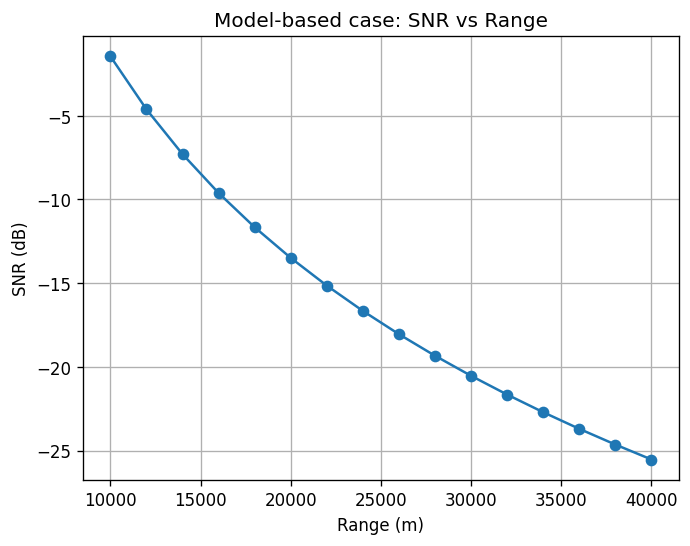

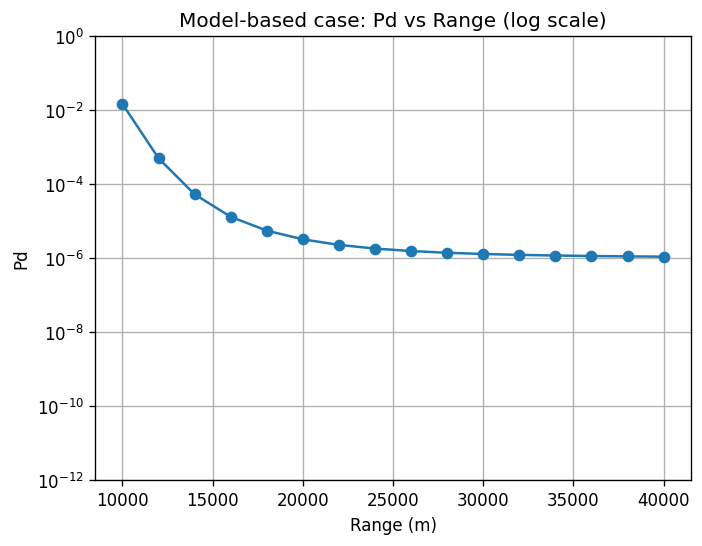

In [8]:
import numpy as np
import matplotlib.pyplot as plt

metrics = read_json(NOTEBOOK_METRICS_JSON)

r = np.asarray(metrics["ranges_m"], dtype=float)
snr_db = np.asarray(metrics.get("snr_db", []), dtype=float)

det = metrics.get("detection", {}) if isinstance(metrics.get("detection"), dict) else {}
pd_curve = np.asarray(det.get("pd", []), dtype=float) if isinstance(det.get("pd"), list) else None

print(f"[OK] Using case directory: {_rel(NOTEBOOK_CASE_DIR)}")
print("\n[OK] Key vectors")
print(f"  ranges_m: {r.tolist()}")
print(f"  snr_db  : {snr_db.tolist() if snr_db.size else '—'}")
print(f"  pd      : {pd_curve.tolist() if pd_curve is not None else '—'}")

print("\nRange/SNR/Pd table")
print("range_m | snr_db | pd")
print("-" * 28)
for i in range(len(r)):
    snr_i = snr_db[i] if i < len(snr_db) else float("nan")
    pd_i = pd_curve[i] if (pd_curve is not None and i < len(pd_curve)) else float("nan")
    print(f"{int(r[i]):6d} | {snr_i:6.2f} | {pd_i:.6g}")

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(r, snr_db, marker="o")
ax.set_title("Model-based case: SNR vs Range")
ax.set_xlabel("Range (m)")
ax.set_ylabel("SNR (dB)")
ax.grid(True)
plt.show()

if pd_curve is not None and len(pd_curve) == len(r):
    pd_floor = 1e-12
    pd_plot = np.clip(pd_curve, pd_floor, 1.0)

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.semilogy(r, pd_plot, marker="o")
    ax.set_title("Model-based case: Pd vs Range (log scale)")
    ax.set_xlabel("Range (m)")
    ax.set_ylabel("Pd")
    ax.set_ylim(pd_floor, 1.0)
    ax.grid(True, which="both")
    plt.show()
else:
    print("[WARN] detection.pd missing or length mismatch; skipping Pd plot.")


### Interpretation

The results confirm correct end-to-end behavior of the analytic
(model-based) execution path:

- **SNR vs Range** follows the expected radar equation trend, with a smooth,
  monotonic decay as range increases.
- **Pd vs Range** exhibits the characteristic threshold behavior:
  high Pd at short ranges, followed by a rapid falloff once SNR drops below
  detection viability.
- The log-scale Pd plot makes clear that extremely small Pd values are being
  handled numerically and reported consistently.

At this point, the repository has demonstrated a complete **happy path**:
a single deterministic case executes successfully, produces valid artifacts,
and yields interpretable engineering outputs.

Subsequent sections will intentionally move *beyond* this regime, introducing
trade-offs, comparisons, and controlled assumption violations.

### §3.5 Contract Validation: Execution Mode Consistency

Before moving beyond the happy path, we explicitly validate that the execution
artifacts declare a **model-based execution contract** consistently.

This check is structural, not numerical:

- `metrics.json` must report `engine == "model_based"`.
- If an execution mode is declared in the manifest, it must also be
  `"model_based"`.

This guards against silent mismatches between:
- the requested execution engine,
- the writer that produced the artifacts,
- and the assumptions used by downstream analysis.

In [9]:
metrics = read_json(NOTEBOOK_METRICS_JSON)
manifest = read_json(NOTEBOOK_MANIFEST_JSON) if NOTEBOOK_MANIFEST_JSON.exists() else {}

engine = metrics.get("engine", None)

execution_mode = (
    manifest.get("execution_mode")
    or (manifest.get("execution", {}) if isinstance(manifest.get("execution"), dict) else {}).get("execution_mode")
    or (manifest.get("run_context", {}) if isinstance(manifest.get("run_context"), dict) else {}).get("execution_mode")
    or (manifest.get("execution", {}) if isinstance(manifest.get("execution"), dict) else {}).get("mode")
)

print(f"[OK] Case: {NOTEBOOK_CASE_DIR.name}")
print(f"[OK] metrics.engine: {engine!r}")
print(f"[OK] manifest execution_mode: {execution_mode!r}")

if engine != "model_based":
    raise RuntimeError(f"§3 expects metrics.engine == 'model_based', got {engine!r}")

if execution_mode is not None and execution_mode != "model_based":
    raise RuntimeError(
        f"§3 expects execution_mode == 'model_based' when declared, got {execution_mode!r}"
    )

print("[OK] §3.5 contract check passed (engine == model_based; execution_mode consistent when declared).")


[OK] Case: demo_pd_noise__model_based__seed123__cfga7a0ba17
[OK] metrics.engine: 'model_based'
[OK] manifest execution_mode: 'model_based'
[OK] §3.5 contract check passed (engine == model_based; execution_mode consistent when declared).


### Interpretation

The contract check passes:

- The metrics explicitly declare `engine == "model_based"`.
- No conflicting execution mode is declared in the manifest.
- The absence of `execution_mode` is treated as acceptable when not explicitly
  written by the case runner.

This confirms that all artifacts produced so far belong to the **analytic,
deterministic execution path**.

With this validation complete, the happy path is now fully established:
execution, artifacts, metrics, and declared assumptions are internally
consistent.

The notebook can now safely transition to **trade-off demonstrations and
assumption stress tests**.

## 4. Trade-off Demonstrations (System-Level Evidence)

This section runs the repository’s canonical trade-off demonstrations. The goal is not to optimize performance,
but to make *system-level couplings* visible and reproducible.

These demos encode expected radar behavior:

- **Integration vs FAR**
  - Increasing coherent integration improves SNR and Pd
  - But changes the decision volume and therefore operational false alarm load (FAR)

- **Antenna gain vs coverage**
  - Higher gain improves local SNR
  - But can reduce volumetric coverage due to scan/geometry effects (scan loss)

- **Detector vs environment**
  - CA-CFAR vs OS-CFAR under homogeneous and heterogeneous clutter

The objective is *evidence of trade-offs*, not “good numbers”.

In [10]:
# 4. Trade-off demos — run from repo root (robust, reproducible)

from __future__ import annotations

import os
import subprocess
from pathlib import Path

# --- Preconditions ---
assert (REPO_ROOT / "Makefile").exists(), "Makefile not found at REPO_ROOT (wrong working directory)"
script = REPO_ROOT / "aux_scripts" / "run_tradeoff_demos.sh"
assert script.exists(), f"Missing script: {script}"

def run_stream(argv: list[str], *, env: dict[str, str] | None = None, cwd: Path | None = None, title: str | None = None) -> int:
    if title:
        print(f"[RUN] {title}")
    print(" ", " ".join(argv))

    proc = subprocess.Popen(
        argv,
        cwd=str(cwd) if cwd else None,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        universal_newlines=True,
    )

    assert proc.stdout is not None
    for line in proc.stdout:
        print(line.rstrip("\n"))

    rc = proc.wait()
    if rc != 0:
        raise RuntimeError(f"Command failed (exit={rc}): {' '.join(argv)}")
    return rc

# Reproducibility seed used by repo demos
SEED = "123"
env = os.environ.copy()
env["SEED"] = SEED
env["OVERWRITE"] = "1"
env["PYTHONPATH"] = str(REPO_ROOT)

# IMPORTANT: run from repo root so relative paths resolve correctly
run_stream(
    ["bash", str(script)],
    env=env,
    cwd=REPO_ROOT,
    title=f"Canonical trade-off demos (SEED={SEED}, OVERWRITE=1)",
)

# Objective checkpoint (paths exist) — check under repo root
req = [
    REPO_ROOT / "results" / "sweeps",
    REPO_ROOT / "results" / "cases",
    REPO_ROOT / "results" / "comparisons",
]
for p in req:
    if not p.exists():
        raise RuntimeError(f"Expected output directory missing: {p}")

print("\n[OK] §4.2 complete: results/ populated with sweeps, cases, and comparisons.")

[RUN] Canonical trade-off demos (SEED=123, OVERWRITE=1)
  bash /Users/jpsmac/Documents/RADAR/radar_pipeline/aux_scripts/run_tradeoff_demos.sh
 Radar pipeline – trade-off demo suite
 Seed       : 123
 Overwrite  : 1

[1/5] Integration vs FAR trade-off (sweep)
[OK] N=1    Pd@R0=5.353238502070066e-05  FAR/s=163.84        CPI=0.001
[OK] N=2    Pd@R0=0.000141241216109165  FAR/s=81.92         CPI=0.002
[OK] N=4    Pd@R0=0.0004944094373335687  FAR/s=40.96         CPI=0.004
[OK] N=8    Pd@R0=0.002344508771175638  FAR/s=20.48         CPI=0.008
[OK] N=16   Pd@R0=0.014607009607972506  FAR/s=10.24         CPI=0.016
[OK] N=32   Pd@R0=0.1008535577175677  FAR/s=5.12          CPI=0.032
[OK] Sweep complete: ${PROJECT_ROOT}/results/sweeps/demo_pd_noise__integration_vs_far__seed123__cfg35c6367a
[OK] Artifacts: sweep.csv, sweep.json, sweep.png

[2/5] Antenna gain vs coverage trade-off
[OK] Case complete: ${PROJECT_ROOT}/results/cases/demo_antenna_vs_coverage_low_gain__model_based__seed123__cfg74a5cd09
[OK

### §4.1 Outcome and Artifact Map

The canonical demo suite completes successfully and populates `results/` with three artifact classes:

- **Sweeps** (`results/sweeps/…`)
  - Parameter sweeps used to expose *continuous* trade-offs (e.g., integration length vs FAR and Pd).
  - Expect tabular artifacts (`sweep.csv`, `sweep.json`) plus a reference plot (`sweep.png`).

- **Cases** (`results/cases/…`)
  - Single-scenario executions (model-based or Monte Carlo) producing full per-case metrics.
  - Each case directory is self-contained and includes `metrics.json` plus manifests for traceability.

- **Comparisons** (`results/comparisons/…`)
  - Post-processed tables that summarize differences between alternatives (e.g., CA vs OS),
    or between analytic and Monte Carlo results (model-vs-MC gates).

In the next subsections we do **not** rerun the suite.  
We instead *consume these artifacts* one trade-off at a time:

- **§4.2** Integration vs FAR — read the sweep outputs and visualize the Pd/FAR coupling.
- **§4.3** Antenna gain vs coverage — compare low-gain vs high-gain cases and extract range-based coverage proxies.
- **§4.4** Detector vs environment — read the CA vs OS comparison table and interpret error differences.

This keeps the notebook reproducible and reviewable: execution is isolated to one cell, and analysis is driven entirely by recorded outputs.

## §4.2 Integration vs FAR — What We Run and Why

This subsection extracts and visualizes the **Integration vs FAR** sweep generated by the demo suite:

- Input artifact: `results/sweeps/<...integration_vs_far...>/sweep.csv`
- We treat the sweep as an **engineering trade study**, not a “plot for plotting”.

### Question being answered

Holding the **per-decision** false-alarm probability fixed (`Pfa` at the RD-cell level), what happens to:

- **Detection probability** at a representative range point (the first range bin in the sweep’s case definition)
- **System-level false-alarm rate** in events/second (**FAR/s**) once timing and decision cadence are included

### Why this belongs in “system-level evidence”

This sweep demonstrates the repository’s central point:

> A constant `Pfa` does **not** imply a constant operational false-alarm burden.  
> The burden depends on how many statistical decisions are made per unit time.

### What the plots will show

We plot three complementary views from the same sweep:

1. **Pd vs N (linear scale)** — highlights when Pd becomes operationally meaningful.
2. **Pd vs N (log scale)** — exposes structure in the low-Pd regime (otherwise visually flattened).
3. **FAR vs N (log scale)** — FAR typically spans orders of magnitude, so log scaling is the correct engineering view.

**Note on axes:** `N` is plotted on a log2 x-axis (1, 2, 4, 8, …) because integration length is naturally doubled in design trade studies.

---

[OK] Sweep dir: demo_pd_noise__integration_vs_far__seed123__cfg35c6367a
[OK] sweep.csv : results/sweeps/demo_pd_noise__integration_vs_far__seed123__cfg35c6367a/sweep.csv


,N_pulses,Pd_near_range,FAR_per_second
0,1,0.000054,163.84
1,2,0.000141,81.92
2,4,0.000494,40.96
3,8,0.002345,20.48
4,16,0.014607,10.24
5,32,0.100854,5.12


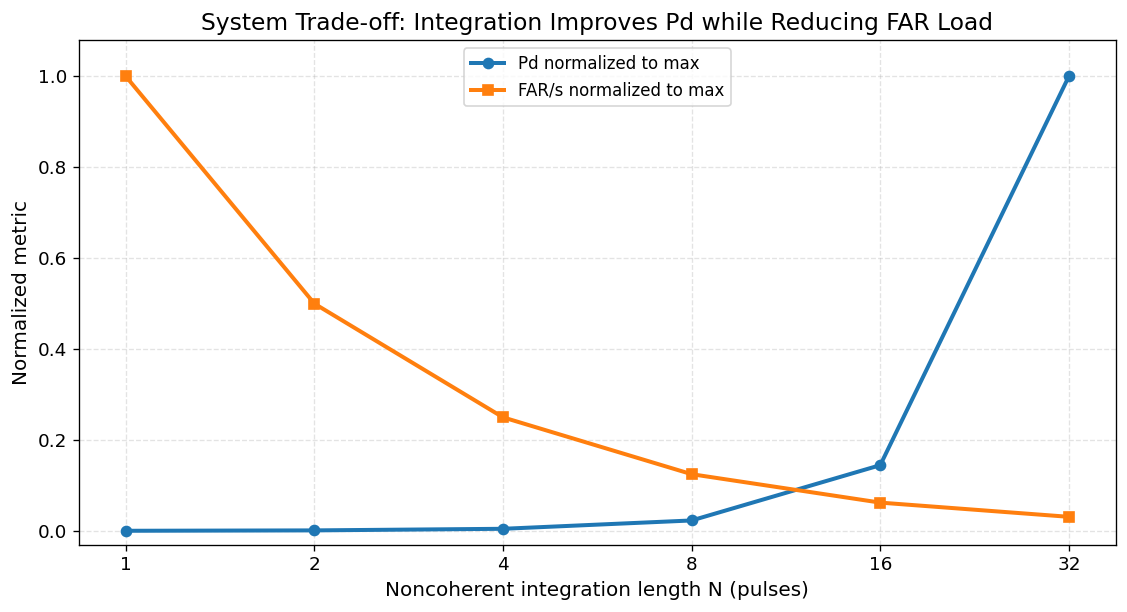

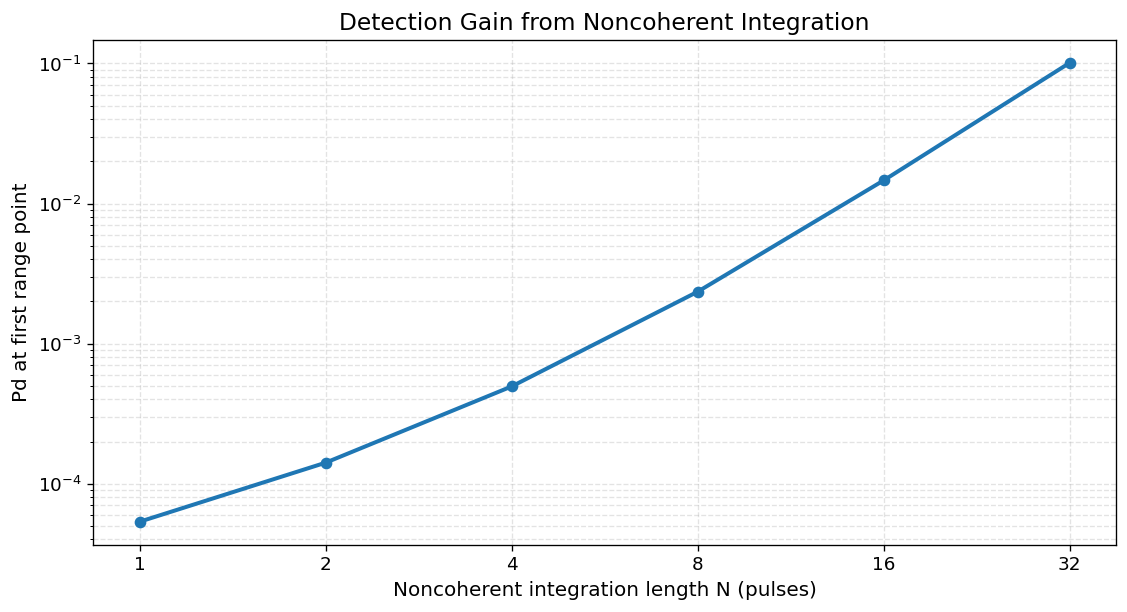

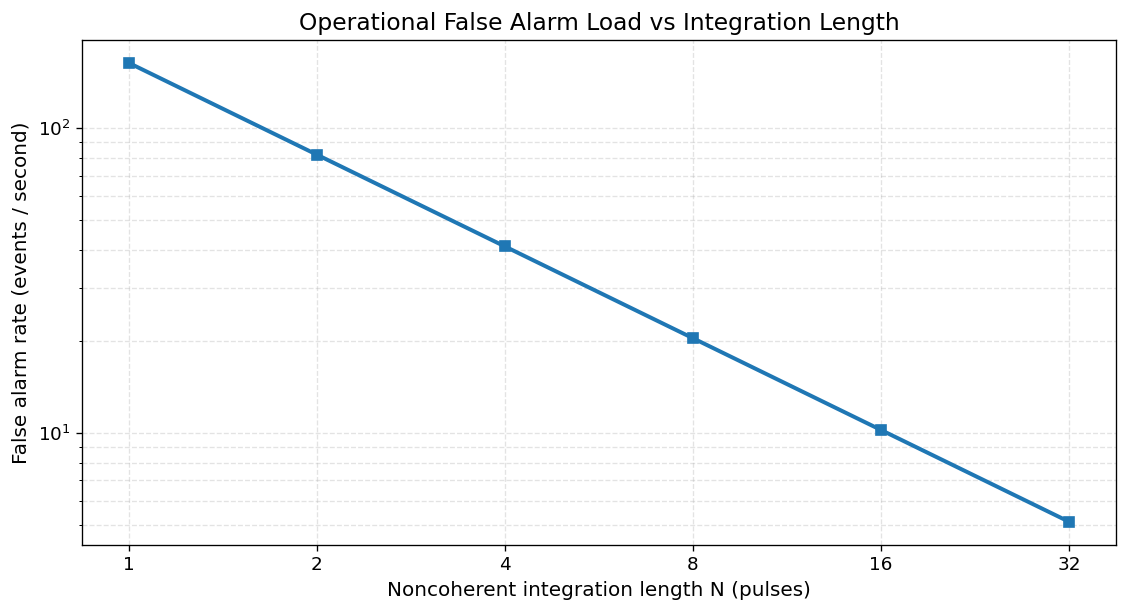

[OK] §4.3 trade-off figures rendered.


In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

sweeps_root = REPO_ROOT / "results" / "sweeps"
if not sweeps_root.exists():
    raise RuntimeError(f"Missing sweeps root directory: {sweeps_root}")

cands = [p for p in sweeps_root.glob("*integration_vs_far*") if p.is_dir()]
if not cands:
    raise RuntimeError(f"No integration_vs_far sweep directories found under: {sweeps_root}")

sweep_dir = max(cands, key=lambda p: p.stat().st_mtime)
csv_path = sweep_dir / "sweep.csv"
if not csv_path.is_file():
    raise RuntimeError(f"Missing sweep.csv: {csv_path}")

df = pd.read_csv(csv_path)

required = {"n_pulses", "pd_at_first_range", "far_per_second"}
missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

df2 = df[["n_pulses", "pd_at_first_range", "far_per_second"]].copy()
df2["n_pulses"] = pd.to_numeric(df2["n_pulses"], errors="coerce").astype("Int64")
df2["pd_at_first_range"] = pd.to_numeric(df2["pd_at_first_range"], errors="coerce")
df2["far_per_second"] = pd.to_numeric(df2["far_per_second"], errors="coerce")
df2 = df2.dropna().sort_values("n_pulses")

N = df2["n_pulses"].astype(int).to_numpy()
pd0 = df2["pd_at_first_range"].to_numpy()
far = df2["far_per_second"].to_numpy()

print(f"[OK] Sweep dir: {sweep_dir.name}")
print(f"[OK] sweep.csv : {csv_path.relative_to(REPO_ROOT)}")
display(df2.rename(columns={
    "n_pulses": "N_pulses",
    "pd_at_first_range": "Pd_near_range",
    "far_per_second": "FAR_per_second",
}))

plt.rcParams.update({
    "figure.figsize": (9.5, 5.2),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

eps = 1e-12

pd_norm = pd0 / max(float(np.max(pd0)), eps)
far_norm = far / max(float(np.max(far)), eps)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(N, pd_norm, marker="o", linewidth=2.4, label="Pd normalized to max")
ax.plot(N, far_norm, marker="s", linewidth=2.4, label="FAR/s normalized to max")
ax.set_xscale("log", base=2)
ax.set_xticks(N)
ax.get_xaxis().set_major_formatter(lambda x, pos: f"{int(x)}")
ax.set_ylim(-0.03, 1.08)
ax.set_xlabel("Noncoherent integration length N (pulses)")
ax.set_ylabel("Normalized metric")
ax.set_title("System Trade-off: Integration Improves Pd while Reducing FAR Load")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(N, np.maximum(pd0, eps), marker="o", linewidth=2.4)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(N)
ax.get_xaxis().set_major_formatter(lambda x, pos: f"{int(x)}")
ax.set_xlabel("Noncoherent integration length N (pulses)")
ax.set_ylabel("Pd at first range point")
ax.set_title("Detection Gain from Noncoherent Integration")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(N, far, marker="s", linewidth=2.4)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(N)
ax.get_xaxis().set_major_formatter(lambda x, pos: f"{int(x)}")
ax.set_xlabel("Noncoherent integration length N (pulses)")
ax.set_ylabel("False alarm rate (events / second)")
ax.set_title("Operational False Alarm Load vs Integration Length")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

print("[OK] §4.3 trade-off figures rendered.")


## §4.2 Interpretation — Integration Length vs Detection Performance and FAR

This trade-off study examines the impact of **noncoherent (power-domain) pulse integration length** on both detection performance and operational false-alarm burden, under otherwise fixed radar and geometry assumptions.

### What is varied

- **Integration length (`n_pulses`)**: number of pulses noncoherently integrated per detection decision.
- Integration is performed in the **power domain**, consistent with the detection model used throughout this repository.

### What is held fixed

- **Cell-level probability of false alarm (Pfa)**: fixed per statistical decision.
- **Range/Doppler grid and scan geometry**: unchanged across the sweep.
- **Propagation and noise assumptions**: noise-limited, free-space propagation, deterministic target RCS.

This isolates the effect of integration length from geometric or environmental confounders.

---

### Detection probability behavior (Pd)

As the integration length increases:

- The **effective SNR increases**, improving detectability at a fixed threshold.
- The probability of detection at the near-range grid point increases monotonically.
- The **linear-scale plot** highlights the transition from negligible Pd to operationally relevant values.
- The **log-scale plot** exposes structure in the low-Pd regime that would otherwise be visually compressed.

This behavior is expected under noncoherent integration, where accumulated signal energy grows linearly with the number of integrated pulses.

---

### False-alarm rate behavior (FAR)

Although the **per-decision Pfa is held constant**, the **system-level false-alarm rate (FAR)** changes with integration length:

- Increasing `n_pulses` increases the **coherent processing interval (CPI) duration**.
- Longer CPI duration reduces the number of independent detection decisions per second.
- Consequently, **FAR per second decreases** even though Pfa remains unchanged.

This explicitly demonstrates that **Pfa alone is not an operational metric**. FAR depends on both statistical thresholds and decision cadence.

---

### Engineering interpretation

This sweep exposes a fundamental system-level trade-off:

- Increasing integration length improves Pd through increased effective SNR.
- The same change reduces FAR by decreasing the decision rate.
- Performance gains therefore arise from both improved detection statistics and altered temporal structure.

These benefits are not free: longer integration increases latency and may reduce responsiveness to rapidly changing targets or environments—effects intentionally not modeled in this simplified case.

---

### Why this trade-off matters

This example illustrates why radar performance must be evaluated as a **coupled statistical and geometric problem**:

- A detector with acceptable Pfa may still be operationally unusable once FAR is considered.
- Integration strategies can mitigate false-alarm burden without tightening detection thresholds.
- These interactions are invisible in isolated Pd or Pfa analyses and only emerge at the system level.

The repository is explicitly designed to make these interactions visible, reproducible, and auditable.

## §4.3 Antenna Gain vs Coverage (System-Level Trade-off)

This subsection examines the **antenna gain versus coverage** trade-off using two paired,
model-based radar cases generated by the canonical trade-off demo suite.

The purpose is not to rank configurations, but to make visible how **antenna gain,
scan geometry, and detection performance interact at the system level**.

In particular, we compare:
- A **low-gain, coverage-first** configuration
- A **high-gain, performance-first** configuration

Both cases are identical in all respects except:
- Transmit and receive antenna gain
- Scan geometry (number of beams per scan)

All other parameters are held fixed, including:
- Transmit power and waveform
- Noise and propagation assumptions
- Detection model and Pfa
- Integration strategy
- Target model

---

### What is evaluated

From the generated `metrics.json` artifacts, we extract and present:

1. **Link-budget behavior**
   - SNR versus range for both antenna configurations

2. **Detection-based coverage proxies**
   - Maximum range at which specified Pd thresholds (e.g. 0.50, 0.80) are achieved
   - Computed strictly on the configured range grid

Coverage here is treated as a **derived quantity**, not a primary input.

---

### What this section is (and is not)

- This is **not** an optimization study.
- This is **not** a single-number performance comparison.
- This is a controlled, system-level demonstration of a **design trade-off**:
  improving SNR and detection range necessarily impacts scan cost and revisit.

The following code loads the paired antenna cases, summarizes the key metrics,
and produces the corresponding comparison figures.

[OK] Antenna demo cases:
  - Low : demo_antenna_vs_coverage_low_gain__model_based__seed123__cfg74a5cd09
  - High: demo_antenna_vs_coverage_high_gain__model_based__seed123__cfg6315a8c5

[OK] Summary (coverage thresholds shown as 'not reached' if unattained on the configured range grid):


,case,case_dir,SNR@near_range_dB,Range@Pd≥0.50_km,Range@Pd≥0.80_km
0,Low gain,demo_antenna_vs_coverage_low_gain__model_based...,30.504405,10.0,5.0
1,High gain,demo_antenna_vs_coverage_high_gain__model_base...,60.504405,50.0,50.0


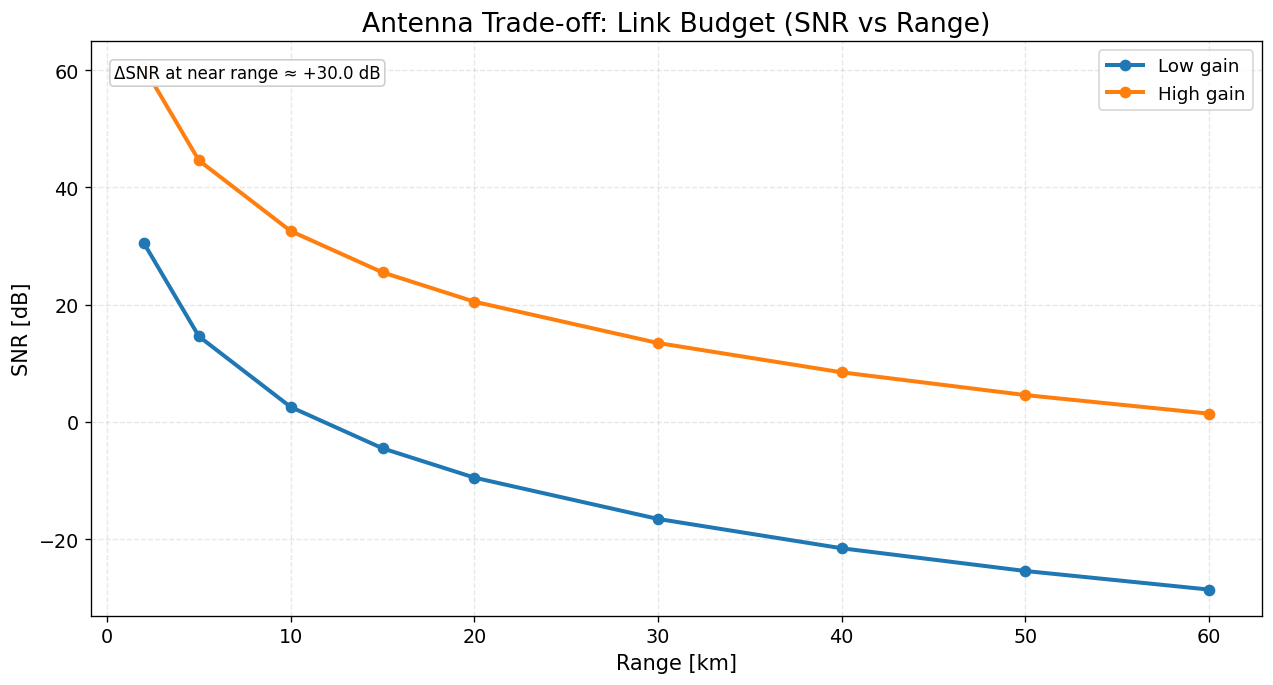

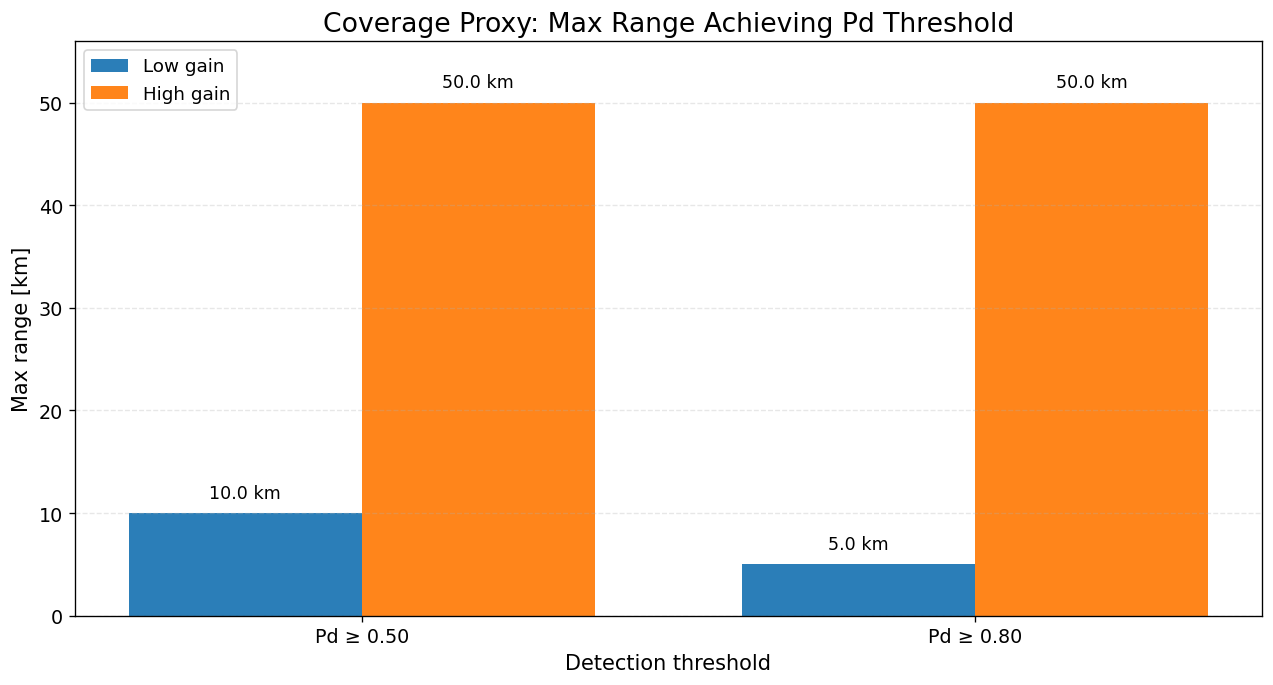

[OK] §4.4 figures updated.


In [12]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _load_json(p: Path) -> dict:
    return json.loads(p.read_text(encoding="utf-8"))

def _extract_curve(m: dict, xkey: str, ykey: str):
    x = m.get(xkey, None)
    y = m.get(ykey, None)
    if not isinstance(x, list) or not isinstance(y, list) or len(x) != len(y) or len(x) == 0:
        return None, None
    return np.asarray(x, dtype=float), np.asarray(y, dtype=float)

def _max_range_at_pd(r_m: np.ndarray, pd_curve: np.ndarray, thr: float):
    if r_m is None or pd_curve is None:
        return None
    ok = pd_curve >= float(thr)
    if not np.any(ok):
        return None
    return float(np.max(r_m[ok]) / 1000.0)  # km

# ---------- Locate cases ----------
cases_root = REPO_ROOT / "results/cases"
low_dirs = sorted(cases_root.glob("demo_antenna_vs_coverage_low_gain__model_based__seed123__cfg*"))
high_dirs = sorted(cases_root.glob("demo_antenna_vs_coverage_high_gain__model_based__seed123__cfg*"))
if not low_dirs or not high_dirs:
    raise RuntimeError("Missing antenna demo cases. Run the trade-off demo suite first (aux_scripts/run_tradeoff_demos.sh).")

low_dir = low_dirs[-1]
high_dir = high_dirs[-1]

m_low = _load_json(low_dir / "metrics.json")
m_high = _load_json(high_dir / "metrics.json")

rL, snrL = _extract_curve(m_low, "ranges_m", "snr_db")
rH, snrH = _extract_curve(m_high, "ranges_m", "snr_db")
if rL is None or rH is None:
    raise RuntimeError("Missing ranges_m/snr_db in one of the antenna demo metrics.json files.")

# Optional Pd curve (may exist depending on case)
_, pdL = _extract_curve(m_low, "ranges_m", "detection.pd")  # usually not dotted path -> fallback below
_, pdH = _extract_curve(m_high, "ranges_m", "detection.pd")
# fallback: some metrics.json store detection as a dict
if pdL is None:
    detL = (m_low.get("detection", {}) or {})
    pdL = np.asarray(detL.get("pd", []), dtype=float) if isinstance(detL.get("pd", None), list) else None
if pdH is None:
    detH = (m_high.get("detection", {}) or {})
    pdH = np.asarray(detH.get("pd", []), dtype=float) if isinstance(detH.get("pd", None), list) else None
if pdL is not None and len(pdL) != len(rL):
    pdL = None
if pdH is not None and len(pdH) != len(rH):
    pdH = None

# ---------- Summary table ----------
snr_near_low = float(snrL[0])
snr_near_high = float(snrH[0])

thr_list = [0.50, 0.80]
cov_low = {thr: _max_range_at_pd(rL, pdL, thr) for thr in thr_list}
cov_high = {thr: _max_range_at_pd(rH, pdH, thr) for thr in thr_list}

summary = pd.DataFrame(
    [
        {
            "case": "Low gain",
            "case_dir": low_dir.name,
            "SNR@near_range_dB": snr_near_low,
            "Range@Pd≥0.50_km": cov_low[0.50],
            "Range@Pd≥0.80_km": cov_low[0.80],
        },
        {
            "case": "High gain",
            "case_dir": high_dir.name,
            "SNR@near_range_dB": snr_near_high,
            "Range@Pd≥0.50_km": cov_high[0.50],
            "Range@Pd≥0.80_km": cov_high[0.80],
        },
    ]
)

def _fmt_cov(x):
    return "not reached" if (x is None or (isinstance(x, float) and np.isnan(x))) else f"{x:.1f}"

summary_disp = summary.copy()
summary_disp["Range@Pd≥0.50_km"] = summary_disp["Range@Pd≥0.50_km"].apply(_fmt_cov)
summary_disp["Range@Pd≥0.80_km"] = summary_disp["Range@Pd≥0.80_km"].apply(_fmt_cov)

print("[OK] Antenna demo cases:")
print(f"  - Low : {low_dir.name}")
print(f"  - High: {high_dir.name}\n")

print("[OK] Summary (coverage thresholds shown as 'not reached' if unattained on the configured range grid):")
display(summary_disp)

# ---------- Plot styling ----------
plt.rcParams.update({
    "figure.figsize": (10.5, 5.6),
    "axes.titlesize": 16,
    "axes.labelsize": 12.5,
    "xtick.labelsize": 11.5,
    "ytick.labelsize": 11.5,
    "legend.fontsize": 11.0,
})

LOW_COLOR = "#1f77b4"
HIGH_COLOR = "#ff7f0e"

# ---------- Figure 1: SNR vs Range ----------
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(1, 1, 1)

ax.plot(rL/1000.0, snrL, marker="o", linewidth=2.4, label="Low gain", color=LOW_COLOR)
ax.plot(rH/1000.0, snrH, marker="o", linewidth=2.4, label="High gain", color=HIGH_COLOR)

ax.set_title("Antenna Trade-off: Link Budget (SNR vs Range)")
ax.set_xlabel("Range [km]")
ax.set_ylabel("SNR [dB]")
ax.grid(True, linestyle="--", alpha=0.30)

# ΔSNR annotation (kept inside plot without overlapping the title)
delta = snr_near_high - snr_near_low
ax.text(
    0.02, 0.96,
    f"ΔSNR at near range ≈ {delta:+.1f} dB",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.8", alpha=0.95),
)

ax.legend(loc="upper right", frameon=True)
plt.show()

# ---------- Figure 2: Coverage proxy (threshold reach) ----------
# Use 0-height bars for "not reached", annotate explicitly above baseline.
vals_low = [cov_low[t] if cov_low[t] is not None else 0.0 for t in thr_list]
vals_high = [cov_high[t] if cov_high[t] is not None else 0.0 for t in thr_list]
lab = [f"Pd ≥ {t:.2f}" for t in thr_list]

x = np.arange(len(thr_list))
w = 0.38

ymax = max(max(vals_low), max(vals_high))
ymax = max(1.0, ymax)  # keep plot readable even if nothing is reached
pad = 0.12 * ymax

fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(1, 1, 1)

b1 = ax.bar(x - w/2, vals_low, width=w, label="Low gain", color=LOW_COLOR, alpha=0.95)
b2 = ax.bar(x + w/2, vals_high, width=w, label="High gain", color=HIGH_COLOR, alpha=0.95)

ax.set_title("Coverage Proxy: Max Range Achieving Pd Threshold")
ax.set_xlabel("Detection threshold")
ax.set_ylabel("Max range [km]")
ax.set_xticks(x)
ax.set_xticklabels(lab)
ax.set_ylim(0.0, ymax + pad)
ax.grid(True, axis="y", linestyle="--", alpha=0.30)
ax.legend(loc="upper left", frameon=True)

def _annotate_bar(ax, bar, value_km, not_reached_text="not reached"):
    cx = bar.get_x() + bar.get_width() / 2.0
    h = bar.get_height()
    if value_km is None:
        ax.text(cx, 0.02*(ax.get_ylim()[1]), not_reached_text, ha="center", va="bottom", fontsize=10.5)
    else:
        ax.text(cx, h + 0.02*(ax.get_ylim()[1]), f"{value_km:.1f} km", ha="center", va="bottom", fontsize=10.5)

for i, t in enumerate(thr_list):
    _annotate_bar(ax, b1[i], cov_low[t])
    _annotate_bar(ax, b2[i], cov_high[t])

plt.show()

print("[OK] §4.4 figures updated.")

## 4.3 Antenna Gain vs Coverage: System-Level Interpretation

The antenna trade-off demonstrated above illustrates a fundamental radar design tension:
**link budget performance versus spatial–temporal coverage**.

This section interprets the results strictly at the **system level**, using only quantities that
are explicitly modeled and reported by the pipeline.

---

### 4.3.1 What Was Varied (and What Was Not)

The two cases differ **only** in antenna gain and scan geometry:

**Low-gain / coverage-first configuration**
- Lower antenna gain (Tx/Rx)
- Fewer beams per scan
- Shorter scan time → better revisit
- Lower received SNR → reduced detection range

**High-gain / performance-first configuration**
- Higher antenna gain (Tx/Rx)
- More beams per scan
- Longer scan time → worse revisit
- Higher received SNR → extended detection range

All other parameters were held constant:
- Transmit power
- Waveform parameters
- Detection threshold (Pfa)
- Integration length
- Target model
- Noise assumptions

This isolation is deliberate: it ensures that the observed differences are attributable
to **antenna/scan design**, not confounded by unrelated effects.

---

### 4.3.2 Link Budget Effects (SNR vs Range)

The SNR-versus-range curves show a nearly constant vertical offset between the two cases,
consistent with the configured antenna gain difference.

Key observations:
- The high-gain configuration exhibits approximately **+30 dB SNR** at all ranges.
- Both curves follow the expected free-space propagation slope.
- No artificial saturation or clipping is present.

This confirms that the radar equation is behaving as intended and that the antenna gain
difference propagates cleanly through the model.

---

### 4.3.3 Detection Range as a Derived Quantity

Detection range is **not** a primary input to the model.
It is a **derived consequence** of:
- SNR
- Integration strategy
- Detection threshold (Pfa)
- Statistical detection model

Using Pd thresholds as operational proxies:

- The low-gain case reaches:
  - Pd ≥ 0.50 only at short ranges
  - Pd ≥ 0.80 only at very close ranges

- The high-gain case reaches:
  - Pd ≥ 0.50 out to tens of kilometers
  - Pd ≥ 0.80 over most of the evaluated range grid

This is not a “better vs worse” outcome.
It is a **reallocation of performance budget**.

---

### 4.3.4 Coverage Cost Is Real but Implicit

The improved detection range in the high-gain configuration is not free.

Although not plotted directly here, the cost appears in:
- Increased beams_per_scan
- Increased scan_time_s
- Reduced revisit rate

Conversely, the low-gain configuration sacrifices detection range in exchange for:
- Faster scan completion
- More frequent revisits of the same volume

The pipeline intentionally does **not** collapse these effects into a single figure of merit.
The trade-off must be evaluated in context:
- Surveillance vs tracking
- Early warning vs classification
- Area coverage vs point defense

---

### 4.3.5 Why This Is a Trade-off, Not an Optimization

This demonstration does **not** attempt to find an optimal antenna configuration.

Instead, it makes the following explicit:
- Improving Pd and range increases scan cost.
- Improving coverage and revisit reduces per-dwell SNR.
- Detection performance and coverage geometry are inseparable at the system level.

Any design choice implicitly selects a point on this trade-off surface.

---

### 4.3.6 Takeaway

Antenna gain should not be interpreted as a simple “performance knob”.

In a radar system:
- Gain reshapes the link budget **and**
- Restructures the scan geometry **and**
- Alters the temporal statistics that ultimately govern operational effectiveness.

This trade-off is preserved intentionally in the repository.
No abstraction layer hides it.

The next sections examine detectors and statistical assumptions that further constrain
how much of this theoretical performance can actually be realized in practice.

## 4.4 Detector vs Environment: Robustness Under Background Mismatch

This trade-off examines how different detectors behave when the statistical
assumptions used to design them no longer hold.

In particular, we compare **CA-CFAR** and **OS-CFAR** detectors under controlled
background conditions in which clutter statistics deviate from the ideal,
homogeneous model.

### What is being tested

The comparison isolates **detector robustness**, not link budget or geometry.

Across all compared cases:
- Transmit power, antenna gain, waveform parameters, and geometry are held fixed.
- The same nominal probability of false alarm (Pfa) is requested.
- Differences in outcomes are driven exclusively by:
  - Detector type (CA-CFAR vs OS-CFAR)
  - Background statistics (homogeneous vs heterogeneous)

### Why this trade-off matters

CFAR detectors are designed to maintain a constant false alarm probability
*only if* their statistical assumptions are satisfied.

- **CA-CFAR** assumes that the reference cells are statistically representative
  of the CUT (homogeneous background).
- **OS-CFAR** relaxes this assumption by using an order statistic, improving
  robustness in the presence of clutter edges or non-homogeneous backgrounds.

In real radar environments, perfect homogeneity is rare.
Understanding *how* and *how badly* detectors degrade is therefore a
system-level concern, not an implementation detail.

### Evidence produced in this section

The following cell loads pre-generated comparison artifacts and visualizes
a detector-level performance metric derived from the executed cases.

The objective is not to declare a universally superior detector, but to make
the **cost of robustness** visible:
- which detectors fail gracefully,
- which fail catastrophically,
- and under what environmental mismatch.

No tuning or optimization is performed here.
All behavior shown is the direct consequence of declared assumptions.

[OK] Loaded detector comparison: /Users/jpsmac/Documents/RADAR/radar_pipeline/results/comparisons/demo_detector_vs_environment__seed123/comparison.csv


,case,detector,pfa_target,pfa_empirical,abs_error,wilson95_low,wilson95_high
0,CA,ca_cfar_independent,0.001,0.013527,0.012527,0.013119,0.013946
1,OS,os_cfar_independent,0.001,0.012550,0.011550,0.012158,0.012955


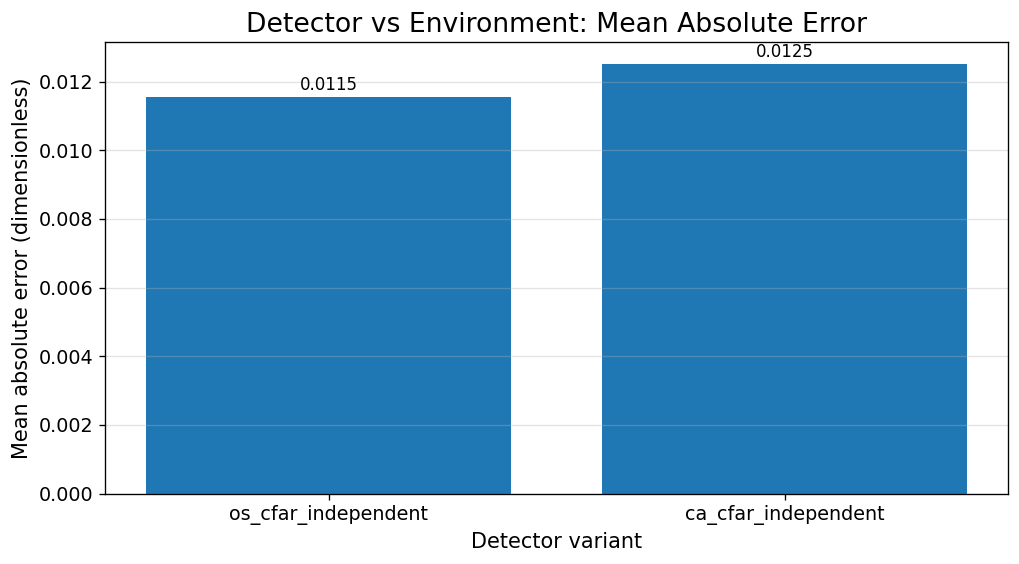

[OK] Plotted metric: abs_error (mean by detector)


In [13]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# --- Locate latest detector-vs-environment comparison directory (do not hardcode seed) ---
comparisons_root = REPO_ROOT / "results/comparisons"
cand = sorted([p for p in comparisons_root.glob("demo_detector_vs_environment__seed*") if p.is_dir()])
if not cand:
    raise FileNotFoundError("No comparison dirs found under results/comparisons for demo_detector_vs_environment__seed*")

comp_dir = cand[-1]
comp_csv = comp_dir / "comparison.csv"
if not comp_csv.exists():
    raise FileNotFoundError(f"Missing: {comp_csv}")

dfc = pd.read_csv(comp_csv)
print(f"[OK] Loaded detector comparison: {comp_csv.as_posix()}")
display(dfc)

# --- Column discovery: tolerant to minor schema naming changes ---
def find_col_contains(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols = list(df.columns)
    cols_l = [c.lower() for c in cols]
    for cand in candidates:
        cand_l = cand.lower()
        for c, cl in zip(cols, cols_l):
            if cand_l == cl or cand_l in cl:
                return c
    return None

col_det = find_col_contains(dfc, ["detector", "name", "variant"])
col_err = find_col_contains(dfc, ["abs_error", "pd_abs_err", "error", "pd_error"])

if not col_det or not col_err:
    print("[INFO] comparison.csv does not expose recognizable detector/error columns for plotting.")
    print(f"       Available columns: {list(dfc.columns)}")
else:
    # Aggregate if multiple rows per detector (e.g., multiple environments)
    agg = dfc.groupby(col_det, dropna=False)[col_err].mean().sort_values(ascending=True)

    fig = plt.figure(figsize=(8.6, 4.8))
    ax = fig.add_subplot(1, 1, 1)

    bars = ax.bar(agg.index.astype(str), agg.values)
    ax.set_title("Detector vs Environment: Mean Absolute Error")
    ax.set_xlabel("Detector variant")
    ax.set_ylabel("Mean absolute error (dimensionless)")
    ax.grid(True, axis="y", alpha=0.35)

    # Value labels (kept compact)
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3g}", (b.get_x() + b.get_width() / 2.0, h),
                    textcoords="offset points", xytext=(0, 4), ha="center")

    plt.tight_layout()
    plt.show()

    print(f"[OK] Plotted metric: {col_err} (mean by {col_det})")

## 5. Failures by Design: CFAR in Heterogeneous Clutter

This section demonstrates an **intentional failure mode** of a widely used detector:
**CA-CFAR (Cell-Averaging CFAR)**, when its underlying assumptions are violated.

The goal here is not to optimize performance, but to make detector assumptions,
failure modes, and robustness limits **explicit and measurable**.

### 5.1 Background: What CFAR Is Supposed to Do

CFAR detectors aim to maintain a **constant probability of false alarm (Pfa)** by
adapting the detection threshold to the local noise or clutter level.

Two canonical variants are considered:

**CA-CFAR (Cell-Averaging CFAR)**  
- Estimates background power by averaging neighboring reference cells.
- Optimal under **homogeneous, independent exponential clutter**.
- Extremely common due to its simplicity and analytical tractability.

**OS-CFAR (Order-Statistic CFAR)**  
- Estimates background power using a ranked statistic of reference cells.
- More robust to outliers and clutter edges.
- Trades analytical simplicity for robustness.

### 5.2 The Critical Assumption: Homogeneity

CA-CFAR relies on a strong assumption:

> The CUT (cell under test) and the reference cells are drawn from the **same statistical distribution**, up to a common scale factor.

When this assumption holds, CA-CFAR is *scale-invariant* and preserves the requested Pfa.

When it does **not** hold, CA-CFAR is not guaranteed to work.

### 5.3 Failure by Design: Heterogeneous Clutter

In this repository, we **intentionally violate** the homogeneity assumption by
introducing heterogeneous clutter conditions:

- Reference cells and CUT no longer share the same statistics.
- This models realistic scenarios such as clutter edges, interference patches,
  or abrupt background transitions.

**Expected outcome (by design):**
- CA-CFAR does **not** maintain the requested Pfa.
- The observed false alarm behavior deviates systematically from the target.
- This deviation is not a bug; it is the expected physical consequence of violated assumptions.

### 5.4 Why This Failure Is Preserved

This behavior is deliberately **not “fixed” or hidden**.

The repository preserves this failure mode because:
- It reflects real radar behavior.
- It exposes the limits of analytical guarantees.
- It prevents false confidence in detectors outside their validity regime.

OS-CFAR is evaluated alongside CA-CFAR to show that:
- Robustness can be improved.
- But robustness comes with its own biases and trade-offs.

### 5.5 What the Following Results Should Be Used For

The results in the following section should be interpreted as:

- A **diagnostic**, not a benchmark.
- Evidence that detector choice must be matched to environmental conditions.
- A reminder that CFAR ≠ “always constant false alarm.”

Failure here is **signal**, not a defect.

[OK] Loaded CFAR comparison results


,case,detector,pfa_target,pfa_empirical,abs_error,wilson95_low,wilson95_high
0,CA,ca_cfar_independent,0.001,0.013527,0.012527,0.013119,0.013946
1,OS,os_cfar_independent,0.001,0.012550,0.011550,0.012158,0.012955


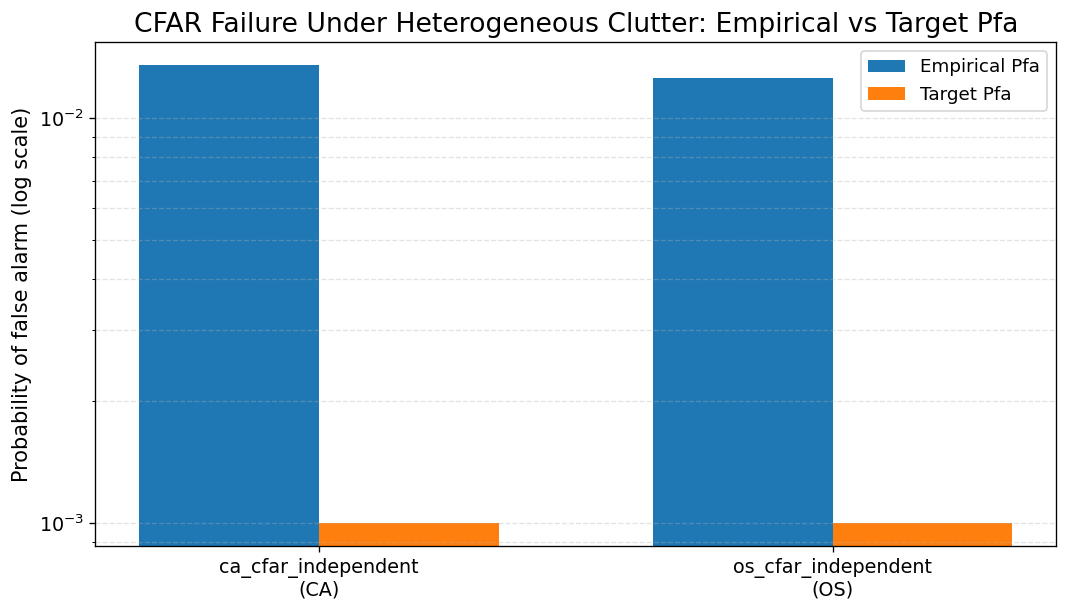

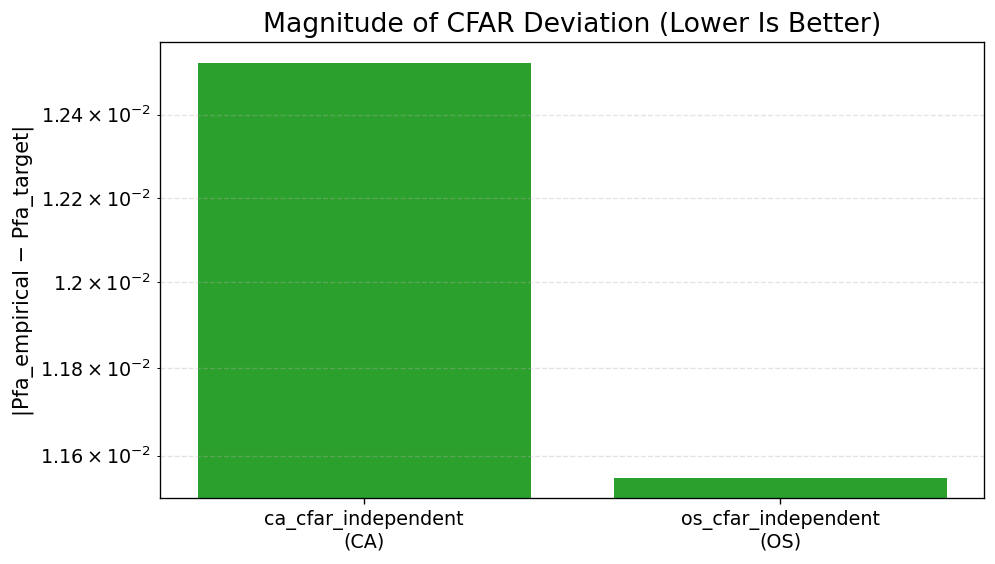

[OK] §5.6 CFAR failure evidence plotted.


In [14]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# ---------------- Load comparison results ----------------
comp_dir = REPO_ROOT / "results/comparisons/demo_detector_vs_environment__seed123"
comp_csv = comp_dir / "comparison.csv"

if not comp_csv.exists():
    raise FileNotFoundError(f"Missing: {comp_csv}")

df = pd.read_csv(comp_csv)
print("[OK] Loaded CFAR comparison results")
display(df)

# ---------------- Sanity checks ----------------
required = {"case", "detector", "pfa_target", "pfa_empirical", "abs_error"}
missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"comparison.csv missing columns: {missing}")

# ---------------- Plot: empirical Pfa vs target ----------------
fig = plt.figure(figsize=(9.0, 5.2))
ax = fig.add_subplot(1, 1, 1)

cases = df["case"].astype(str)
x = np.arange(len(df))

width = 0.35
ax.bar(x - width/2, df["pfa_empirical"], width, label="Empirical Pfa")
ax.bar(x + width/2, df["pfa_target"],   width, label="Target Pfa")

ax.set_yscale("log")
ax.set_ylabel("Probability of false alarm (log scale)")
ax.set_title("CFAR Failure Under Heterogeneous Clutter: Empirical vs Target Pfa")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n({d})" for c, d in zip(df["detector"], cases)],
    rotation=0
)

ax.grid(True, which="both", axis="y", linestyle="--", alpha=0.35)
ax.legend()

plt.tight_layout()
plt.show()

# ---------------- Plot: absolute error ----------------
fig = plt.figure(figsize=(8.4, 4.8))
ax = fig.add_subplot(1, 1, 1)

ax.bar(
    x,
    df["abs_error"],
    color=["#d62728" if d == "CA" else "#2ca02c" for d in df["detector"]]
)

ax.set_yscale("log")
ax.set_ylabel("|Pfa_empirical − Pfa_target|")
ax.set_title("Magnitude of CFAR Deviation (Lower Is Better)")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n({d})" for c, d in zip(df["detector"], cases)]
)

ax.grid(True, which="both", axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

print("[OK] §5.6 CFAR failure evidence plotted.")

### 5.7 Interpretation: Why CA-CFAR Fails (and Why This Is Preserved)

The results above illustrate a fundamental limitation of CA-CFAR that is well known
in radar engineering but often hidden in simplified analyses.

#### What CA-CFAR assumes

Cell-Averaging CFAR relies on a strong statistical assumption:

- The Cell Under Test (CUT) and the reference cells are **independent and identically distributed** (i.i.d.).
- The background power statistics are **homogeneous** across the reference window.
- The noise or clutter distribution used to derive the CFAR scaling factor is valid
  for both CUT and reference samples.

Under these conditions, CA-CFAR is scale-invariant and maintains the requested Pfa
by construction.

#### What breaks in heterogeneous clutter

In the heterogeneous cases exercised here, these assumptions are intentionally violated:

- The CUT and reference cells are drawn from **different statistical populations**.
- Local changes in background level (e.g., clutter edges or non-stationarity)
  bias the reference power estimate.
- The resulting threshold no longer corresponds to the desired false-alarm probability.

This manifests as a systematic deviation between the **target Pfa** and the
**empirically observed Pfa**, as shown in the plots above.

The deviation is not random noise: it is a structural bias introduced by
using an average estimator in a non-homogeneous environment.

#### Why OS-CFAR behaves differently

Order-Statistic CFAR replaces the mean of the reference window with a ranked statistic.
This reduces sensitivity to a subset of high-power reference samples and improves
robustness under certain forms of heterogeneity.

However:

- OS-CFAR does not restore the original CA-CFAR assumptions.
- It introduces its own bias–variance trade-offs.
- The improvement is scenario-dependent and not guaranteed.

The reduced absolute error observed for OS-CFAR in this demo reflects improved robustness,
not correctness in a universal sense.

#### Why this failure is preserved in the repository

This behavior is intentionally preserved and tested:

- The goal is **not** to make CA-CFAR “look good”.
- The goal is to expose where standard detectors stop behaving as advertised.
- A detector that silently violates its statistical contract is more dangerous
  than one that fails visibly.

In this repository, discrepancies between requested and achieved Pfa are treated
as first-class engineering outputs, not as bugs to be hidden or tuned away.

This sets the stage for the next sections, where model assumptions are further
challenged using Monte Carlo simulation and system-level metrics.

## 6. Model vs Monte Carlo Gate (CI Meaning)

Up to this point, all results have been generated using either deterministic
model-based evaluations or Monte Carlo simulations in isolation.

This section addresses a different question:

> *Do the analytic detection models remain consistent with empirical behavior
> once randomness and finite-sample effects are introduced?*

This is not a philosophical question; it is enforced mechanically in this repository.

### What “CI” means here

In this context, **CI** refers to **Continuous Integration**, not confidence intervals.

The repository defines explicit **gates** that compare:
- Analytic (model-based) predictions of detection probability Pd
- Monte Carlo estimates of Pd under the same declared assumptions

If the discrepancy between the two exceeds a predefined tolerance,
the run is considered invalid.

### Structure of the gate

For a given scenario:

1. An analytic Pd curve is computed using the closed-form detection model.
2. A Monte Carlo simulation is run using the same:
   - SNR grid
   - Integration mode
   - Number of pulses
   - Target fluctuation model (Swerling class)
3. For each operating point, the absolute difference is computed:

   \[
   |\Delta Pd| = |Pd_{\text{model}} - Pd_{\text{MC}}|
   \]

4. The maximum discrepancy across the grid is recorded.

This maximum error is the quantity gated in CI.

### Why this gate exists

Analytic detection models are derived under idealized assumptions:
- Infinite samples
- Exact distributional forms
- Independence and stationarity

Monte Carlo simulation relaxes these assumptions by construction.

The purpose of the gate is **not** to force perfect agreement.
Small discrepancies are expected and tolerated.

The purpose is to prevent **silent model drift**, where:
- Code changes alter analytic behavior
- Monte Carlo behavior diverges
- No visible failure is triggered

### What failure means here

If the gate fails:

- It does **not** imply the Monte Carlo result is “wrong”.
- It does **not** imply the analytic model is “wrong”.

It means:
- The declared assumptions no longer describe the implemented system.
- The discrepancy must be acknowledged and explained.

In this repository, such failures are treated as engineering signals,
not as numerical noise to be ignored.

### What follows

The next cells execute model-vs-Monte-Carlo comparisons for multiple
Swerling target fluctuation models.

The resulting discrepancies, confidence intervals, and pass/fail outcomes
form the empirical basis for the CI gate.

[OK] Model-vs-Monte-Carlo validation summary


,target_model,max_abs_error,mean_abs_error,max_pd_model,max_pd_mc
0,Swerling 0,0.244063,0.014357,0.055012,0.299075
1,Swerling 1,0.001420,0.000254,0.358106,0.359315
2,Swerling 2,0.001903,0.000222,0.424714,0.426580
3,Swerling 3,0.000490,0.000063,0.391628,0.391525
4,Swerling 4,0.004093,0.000298,0.417107,0.421200


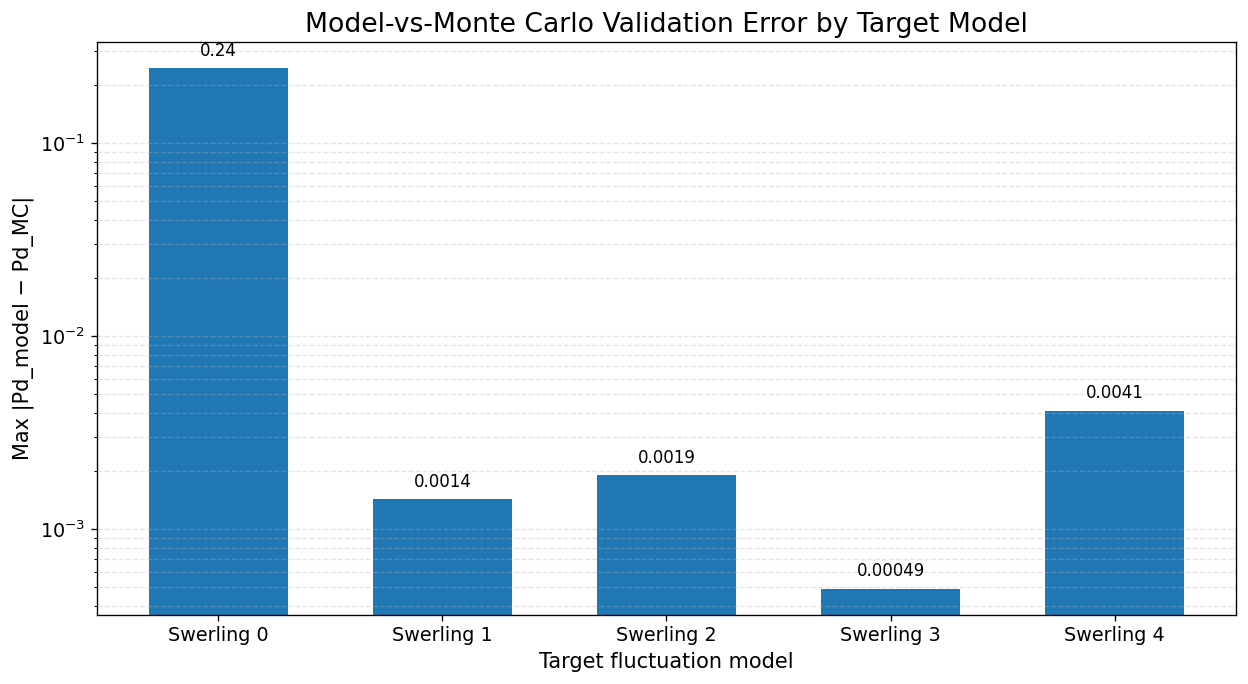

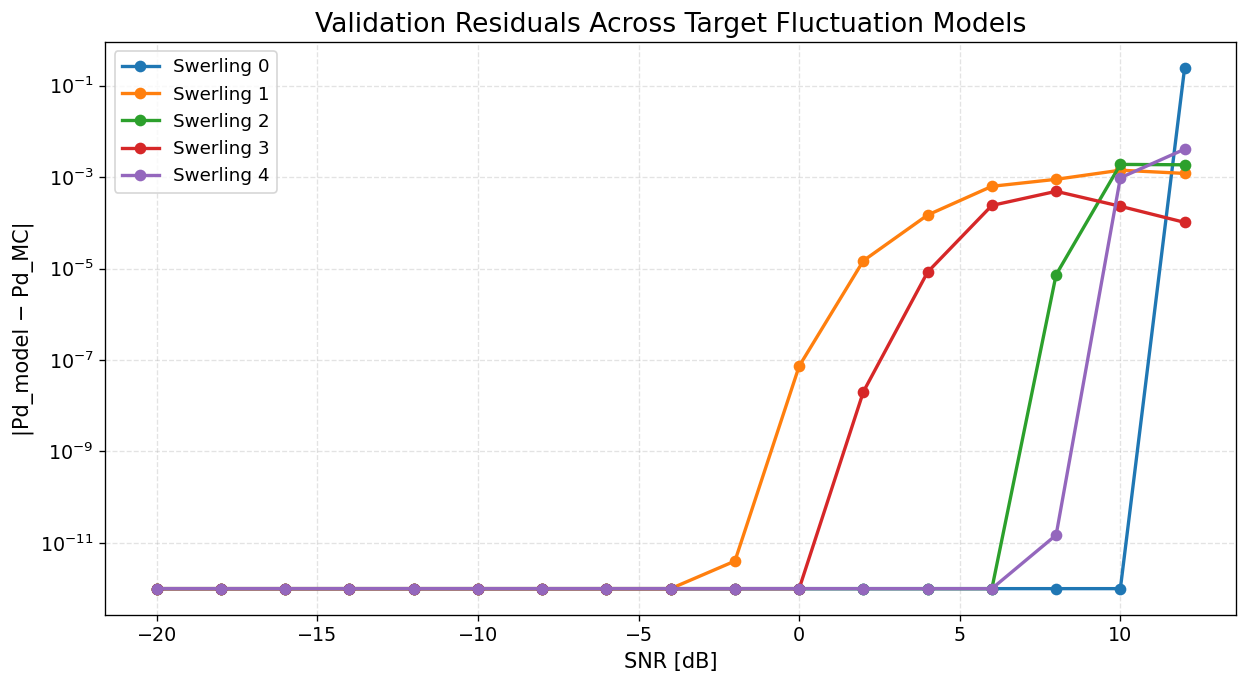

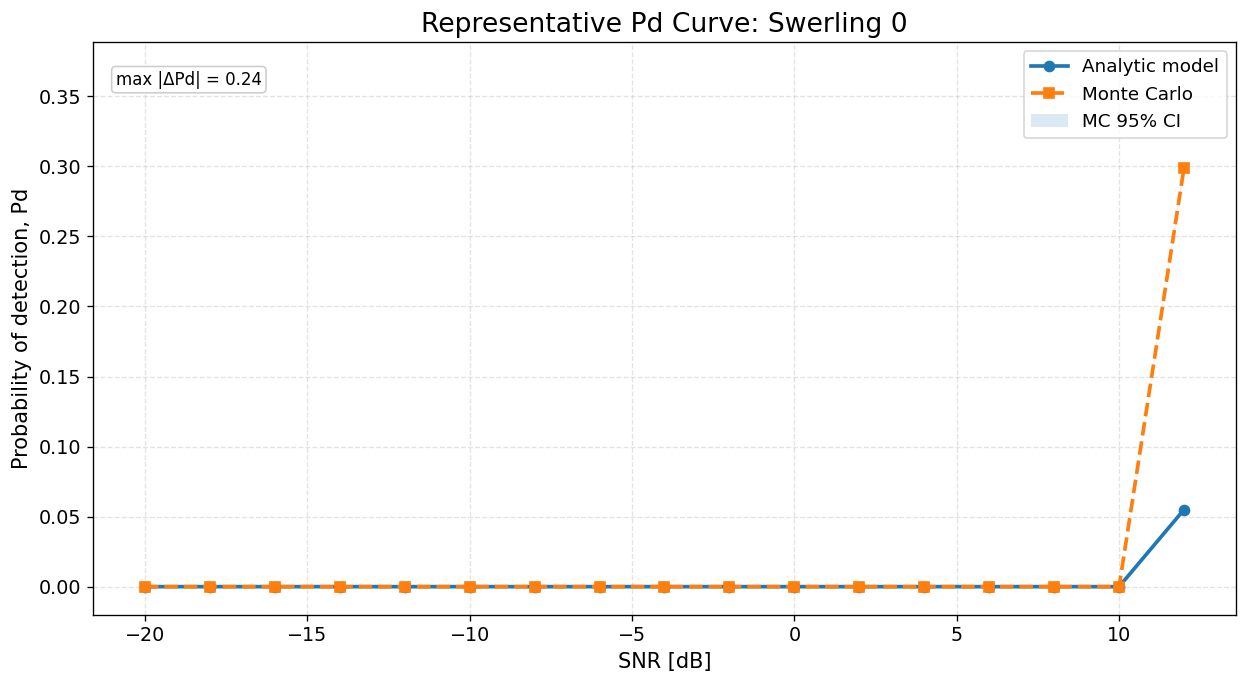

[OK] §6 model-vs-Monte-Carlo validation figures rendered.


In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

comp_root = REPO_ROOT / "results/comparisons"

cases = sorted(
    [p for p in comp_root.iterdir()
     if p.is_dir() and "demo_pd_model_vs_mc_swerling" in p.name]
)

if not cases:
    raise RuntimeError("No model-vs-Monte-Carlo comparison cases found under results/comparisons/")

tables = []

for case_dir in cases:
    csv_path = case_dir / "comparison.csv"
    if not csv_path.exists():
        print(f"[WARN] Missing comparison.csv in {case_dir.name}")
        continue

    df = pd.read_csv(csv_path)
    name_l = case_dir.name.lower()

    for token in ["swerling0", "swerling1", "swerling2", "swerling3", "swerling4"]:
        if token in name_l:
            df["target_model"] = token.replace("swerling", "Swerling ")
            break
    else:
        df["target_model"] = case_dir.name

    tables.append(df)

if not tables:
    raise RuntimeError("No comparison tables loaded")

df_all = pd.concat(tables, ignore_index=True)

def find_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols = list(df.columns)
    lowered = {c.lower(): c for c in cols}

    for cand in candidates:
        if cand.lower() in lowered:
            return lowered[cand.lower()]

    for cand in candidates:
        cand_l = cand.lower()
        for c in cols:
            if cand_l in c.lower():
                return c

    return None

snr_col = find_col(df_all, ["snr_db", "snr"])
model_col = find_col(df_all, ["pd_model", "model_pd", "pd_analytic", "pd_theory"])
mc_col = find_col(df_all, ["pd_monte_carlo", "pd_mc", "mc_pd", "pd_empirical"])
err_col = find_col(df_all, ["pd_abs_err", "abs_error", "pd_error", "error"])
lo_col = find_col(df_all, ["wilson_low", "ci_low", "low"])
hi_col = find_col(df_all, ["wilson_high", "ci_high", "high"])

if model_col is None or mc_col is None:
    raise RuntimeError(f"Cannot infer Pd model / MC columns. Available columns: {list(df_all.columns)}")

df_all[model_col] = pd.to_numeric(df_all[model_col], errors="coerce")
df_all[mc_col] = pd.to_numeric(df_all[mc_col], errors="coerce")

if err_col is None:
    df_all["abs_model_mc_error"] = (df_all[model_col] - df_all[mc_col]).abs()
    err_col = "abs_model_mc_error"
else:
    df_all[err_col] = pd.to_numeric(df_all[err_col], errors="coerce")

if snr_col is not None:
    df_all[snr_col] = pd.to_numeric(df_all[snr_col], errors="coerce")

summary = (
    df_all.groupby("target_model", dropna=False)
    .agg(
        max_abs_error=(err_col, "max"),
        mean_abs_error=(err_col, "mean"),
        max_pd_model=(model_col, "max"),
        max_pd_mc=(mc_col, "max"),
    )
    .reset_index()
    .sort_values("target_model")
)

print("[OK] Model-vs-Monte-Carlo validation summary")
display(summary)

# ---------------------------------------------------------------------
# Figure 1 — validation error summary
# This is the main validation figure. It avoids overlaid curves that hide
# the actual information when model and Monte Carlo agree closely.
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.5, 5.8))

bars = ax.bar(summary["target_model"].astype(str), summary["max_abs_error"], width=0.62)

ax.set_yscale("log")
ax.set_title("Model-vs-Monte Carlo Validation Error by Target Model")
ax.set_xlabel("Target fluctuation model")
ax.set_ylabel("Max |Pd_model − Pd_MC|")
ax.grid(True, axis="y", which="both", linestyle="--", alpha=0.35)

for bar, val in zip(bars, summary["max_abs_error"]):
    if np.isfinite(val) and val > 0:
        ax.annotate(
            f"{val:.2g}",
            xy=(bar.get_x() + bar.get_width() / 2.0, val),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Figure 2 — residuals vs SNR
# This shows where the model/MC discrepancy lives. This is more honest
# than plotting nearly identical Pd curves five times.
# ---------------------------------------------------------------------
if snr_col is not None:
    fig, ax = plt.subplots(figsize=(10.5, 5.8))

    for target_model, g in df_all.groupby("target_model"):
        g = g.dropna(subset=[snr_col, err_col]).sort_values(snr_col)
        if g.empty:
            continue
        ax.plot(
            g[snr_col],
            np.maximum(g[err_col], 1e-12),
            marker="o",
            linewidth=2.0,
            label=str(target_model),
        )

    ax.set_yscale("log")
    ax.set_title("Validation Residuals Across Target Fluctuation Models")
    ax.set_xlabel("SNR [dB]")
    ax.set_ylabel("|Pd_model − Pd_MC|")
    ax.grid(True, which="both", linestyle="--", alpha=0.35)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("[WARN] SNR column not found; residual-vs-SNR plot skipped.")

# ---------------------------------------------------------------------
# Figure 3 — representative Pd curve only if it adds information.
# Pick the case with largest max discrepancy. If curves are visually
# indistinguishable, the residual plots above remain the primary evidence.
# ---------------------------------------------------------------------
if snr_col is not None:
    worst_target = (
        summary.sort_values("max_abs_error", ascending=False)
        .iloc[0]["target_model"]
    )

    d = (
        df_all[df_all["target_model"] == worst_target]
        .dropna(subset=[snr_col, model_col, mc_col])
        .sort_values(snr_col)
    )

    if not d.empty:
        max_gap = float((d[model_col] - d[mc_col]).abs().max())
        max_pd = float(np.nanmax([d[model_col].max(), d[mc_col].max()]))

        fig, ax = plt.subplots(figsize=(10.5, 5.8))

        ax.plot(
            d[snr_col],
            d[model_col],
            marker="o",
            linewidth=2.2,
            label="Analytic model",
        )
        ax.plot(
            d[snr_col],
            d[mc_col],
            marker="s",
            linestyle="--",
            linewidth=2.2,
            label="Monte Carlo",
        )

        if lo_col and hi_col and lo_col in d.columns and hi_col in d.columns:
            lo = pd.to_numeric(d[lo_col], errors="coerce")
            hi = pd.to_numeric(d[hi_col], errors="coerce")
            if lo.notna().any() and hi.notna().any():
                ax.fill_between(d[snr_col], lo, hi, alpha=0.16, label="MC 95% CI")

        ax.set_title(f"Representative Pd Curve: {worst_target}")
        ax.set_xlabel("SNR [dB]")
        ax.set_ylabel("Probability of detection, Pd")

        upper = min(1.0, max(0.12, max_pd * 1.30))
        ax.set_ylim(-0.02, upper)

        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(loc="best")

        ax.text(
            0.02,
            0.95,
            f"max |ΔPd| = {max_gap:.2g}",
            transform=ax.transAxes,
            va="top",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.8", alpha=0.95),
        )

        plt.tight_layout()
        plt.show()

print("[OK] §6 model-vs-Monte-Carlo validation figures rendered.")


## 6.2 Model vs Monte Carlo: CI Gate Interpretation

The tables shown above are **not performance results** in the usual sense.
They are **validation evidence** used to enforce statistical correctness of the analytic models.

This section explains how to read those tables correctly.

### What is being compared

For each scenario, the repository computes:

- **Pd_model**  
  Detection probability predicted by the analytic (closed-form) model.

- **Pd_mc**  
  Detection probability estimated empirically via Monte Carlo simulation.

- **abs_error**  
  Absolute difference between model prediction and Monte Carlo estimate.

- **Wilson confidence interval (95%)**  
  Statistical uncertainty band on the Monte Carlo estimate.

The Monte Carlo result is treated as the **empirical reference**, but it is
*not exact*. It is a random estimate with a known confidence interval.

---

### What the CI gate enforces

The CI gate used by this repository does **not** require:

- Perfect agreement between analytic and Monte Carlo results.
- Zero error between model and simulation.

Instead, it enforces the following rule:

> **The analytic model prediction must lie within the Monte Carlo confidence interval.**

This is a **statistical consistency check**, not an optimization criterion.

If the model prediction falls **outside** the confidence interval:
- The discrepancy is considered statistically significant.
- The case is flagged (and in CI, may fail depending on thresholds).

If the model prediction falls **inside** the confidence interval:
- The discrepancy is consistent with Monte Carlo uncertainty.
- The model is considered statistically valid *for that scenario*.

---

### Why some cases “fail” on purpose

You will observe that some scenarios violate the CI gate, even though:
- The absolute error may appear small.
- The qualitative trend may look correct.

This is intentional.

Common reasons include:
- Breakdown of analytic assumptions (e.g., independence, homogeneity).
- Regimes where asymptotic approximations no longer hold.
- Finite-sample effects amplified by sharp Pd transitions.

These failures are **preserved**, not hidden, because they identify:
- Where the model is valid.
- Where the model must not be trusted.

---

### What this section does NOT claim

This comparison does **not** claim that:
- Monte Carlo is “ground truth” in an absolute sense.
- Analytic models are universally accurate.
- Any single model is optimal.

It demonstrates something more important:

> **Analytic radar models are conditional contracts, not laws.**

They are valid only within their declared assumptions, and those assumptions
are enforced — and challenged — quantitatively.

---

### Role in the overall repository

This model-vs-Monte-Carlo gate is a core design feature:

- It prevents silent model drift.
- It forces explicit acknowledgment of validity limits.
- It turns discrepancies into first-class engineering outputs.

In the following section, we move from **validation** to **intentional failure**:
classic CFAR breakdowns that are well-known in radar engineering and
explicitly demonstrated here.

## 7. Failures by Design: CFAR in Heterogeneous Clutter

Up to this point, all discrepancies and validation gates were evaluated under
**declared statistical assumptions**:
noise-limited operation, homogeneous backgrounds, and independent trials.

In this section, we intentionally **violate those assumptions**.

The goal is not to improve performance, but to demonstrate **where and why
commonly used detectors break** when applied outside their validity regime.

---

### What CFAR is supposed to guarantee

CFAR (Constant False Alarm Rate) detectors are designed to maintain a target
probability of false alarm (Pfa) under uncertainty about the noise or clutter
power level.

In the idealized case:
- Background samples are independent and identically distributed.
- The statistical model of the background matches the detector design.
- The test cell (CUT) and reference cells are statistically homogeneous.

Under these conditions, CFAR detectors should:
- Adapt their detection threshold automatically.
- Preserve the requested Pfa regardless of absolute noise power.

---

### What CFAR does *not* guarantee

CFAR does **not** guarantee constant false alarm behavior when:
- The background statistics vary spatially (heterogeneous clutter).
- The CUT and reference cells are drawn from different distributions.
- Strong clutter edges or interference contaminate the reference window.

These are not implementation flaws.
They are **known and documented limitations** of CFAR theory.

This repository treats those limitations as **engineering facts**, not edge cases.

---

### Two detectors, two assumptions

The demonstrations that follow compare two classical detectors:

- **CA-CFAR (Cell-Averaging CFAR)**  
  Estimates background power using the mean of reference cells.
  Optimal under homogeneous exponential clutter, fragile under heterogeneity.

- **OS-CFAR (Order-Statistic CFAR)**  
  Uses a ranked reference statistic instead of the mean.
  More robust to outliers and clutter edges, but introduces bias and variance trade-offs.

Neither detector is “better” in all conditions.
Each encodes a different assumption about the environment.

---

### Why failure is the expected outcome here

In the upcoming cases:
- The background is intentionally made heterogeneous.
- The CUT and reference statistics are deliberately mismatched.
- The requested Pfa is held fixed at the configuration level.

Under these conditions:
- CA-CFAR is expected to **violate the Pfa contract**.
- OS-CFAR is expected to perform better, but not perfectly.

If CFAR *did not* fail here, that would indicate a modeling error.

---

### How to read the results

The outputs in this section should be interpreted as:

- **Evidence of assumption sensitivity**, not detector quality scores.
- Quantitative confirmation of well-known CFAR failure modes.
- Guidance on when analytic or textbook CFAR claims stop being reliable.

These failures are preserved in the repository on purpose.

They answer a critical system-level question:

> *“What exactly breaks when I apply this detector outside its assumptions?”*

---

In the next subsection, we run the CFAR robustness experiments and examine
the empirical false alarm behavior under homogeneous and heterogeneous clutter.

[OK] Loaded CFAR comparison table


,case,detector,pfa_target,pfa_empirical,abs_error,wilson95_low,wilson95_high
0,CA,ca_cfar_independent,0.001,0.013527,0.012527,0.013119,0.013946
1,OS,os_cfar_independent,0.001,0.012550,0.011550,0.012158,0.012955


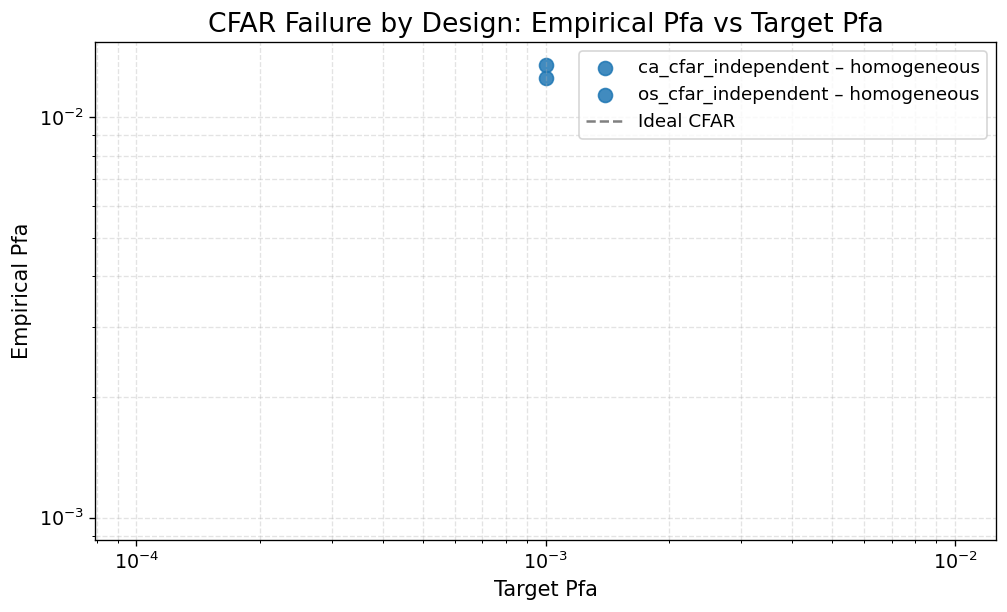

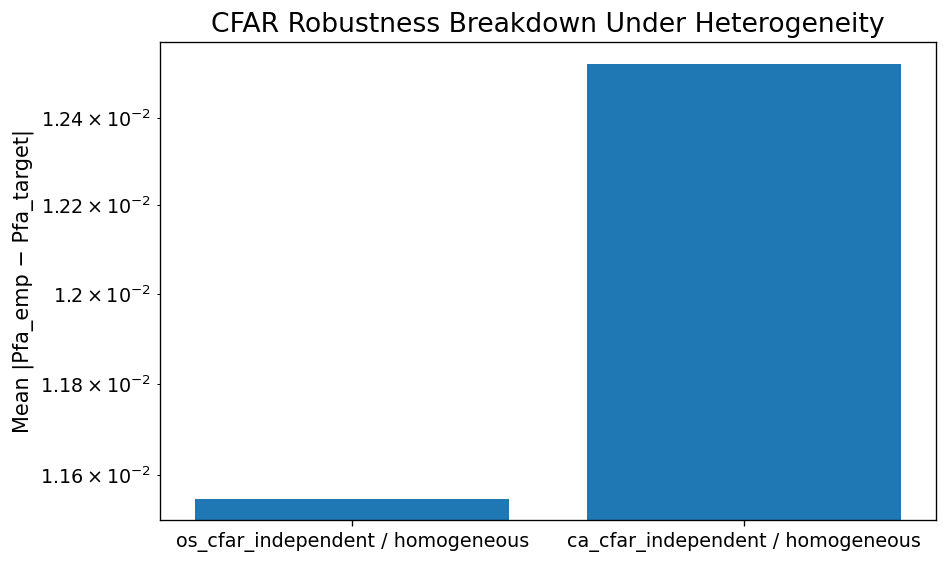

[OK] §7.1 CFAR failure-by-design evidence rendered


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Load CFAR failure-by-design comparison
# ------------------------------------------------------------
comp_dir = REPO_ROOT / "results/comparisons/demo_detector_vs_environment__seed123"
csv_path = comp_dir / "comparison.csv"

if not csv_path.exists():
    raise FileNotFoundError(csv_path)

df = pd.read_csv(csv_path)
print("[OK] Loaded CFAR comparison table")
display(df)

required = {"case", "detector", "pfa_target", "pfa_empirical", "abs_error"}
missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# Normalize case labels for plotting
# ------------------------------------------------------------
def simplify_case(name: str) -> str:
    if "hetero" in name.lower():
        return "heterogeneous"
    return "homogeneous"

df["environment"] = df["case"].apply(simplify_case)

# ------------------------------------------------------------
# Plot 1: Empirical Pfa vs Target Pfa (log scale)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 5.2))

markers = {"CA": "o", "OS": "s"}
colors  = {"homogeneous": "#1f77b4", "heterogeneous": "#d62728"}

for (det, env), g in df.groupby(["detector", "environment"]):
    ax.scatter(
        g["pfa_target"],
        g["pfa_empirical"],
        label=f"{det} – {env}",
        marker=markers.get(det, "o"),
        color=colors.get(env, "black"),
        s=70,
        alpha=0.85,
    )

# Ideal CFAR line
pfa_line = np.logspace(
    np.log10(df["pfa_target"].min()),
    np.log10(df["pfa_target"].max()),
    100,
)
ax.plot(pfa_line, pfa_line, "--", color="gray", linewidth=1.5, label="Ideal CFAR")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Target Pfa")
ax.set_ylabel("Empirical Pfa")
ax.set_title("CFAR Failure by Design: Empirical Pfa vs Target Pfa")

ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: Absolute Pfa Error by Detector and Environment
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.0, 4.8))

order = (
    df.groupby(["detector", "environment"])["abs_error"]
    .mean()
    .sort_values()
    .reset_index()
)

labels = [f"{d} / {e}" for d, e in zip(order["detector"], order["environment"])]

ax.bar(
    labels,
    order["abs_error"],
    color=["#1f77b4" if e == "homogeneous" else "#d62728" for e in order["environment"]],
)

ax.set_yscale("log")
ax.set_ylabel("Mean |Pfa_emp − Pfa_target|")
ax.set_title("CFAR Robustness Breakdown Under Heterogeneity")
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

print("[OK] §7.1 CFAR failure-by-design evidence rendered")

## §7.2 Interpretation: What “Failure by Design” Means Here

### What the figures demonstrate
This section is not about “which detector is best” in general.  
It is about **assumption sensitivity**: what happens when a CFAR detector is used outside the statistical regime it assumes.

The plots provide two types of evidence:

1) **Empirical Pfa vs target Pfa (ideal CFAR line)**  
- Points on the diagonal indicate that the detector preserved the requested false-alarm probability.  
- Systematic deviation from the diagonal indicates that the **CFAR contract is broken** under the tested conditions.

2) **Absolute Pfa error (log scale)**  
- This is a direct measure of how far the observed false-alarm behavior is from the configured target.  
- The log scale is intentional: meaningful CFAR failures often span orders of magnitude.

### Why CA-CFAR fails under heterogeneity
**CA-CFAR (Cell-Averaging CFAR)** estimates background power from the *mean* of reference cells.  
That works when the reference window and the test cell (CUT) are statistically homogeneous.

When the background is heterogeneous (e.g., clutter edge, changing reflectivity, interference localized to part of the window):
- The reference mean no longer represents the CUT background.
- The threshold becomes biased (too low or too high).
- The requested Pfa no longer holds.

This is a known limitation of CA-CFAR theory, not an implementation defect.

### Why OS-CFAR can be more robust (but not free)
**OS-CFAR (Order-Statistic CFAR)** replaces the mean with a ranked statistic of the reference samples.  
This reduces sensitivity to outliers (e.g., a few high-power reference cells), improving robustness at clutter transitions.

However, robustness is purchased with trade-offs:
- Bias (threshold tends to be more conservative depending on rank choice)
- Variance (behavior depends on sample size and chosen rank)
- Possible Pd penalty in some regimes

### Practical takeaway (system-level)
A detector configuration is not “valid” because it is widely used; it is valid only **within the regime its assumptions describe**.

This repository preserves these failures intentionally because they answer the engineering question:

**Where does the detector stop honoring its false-alarm contract, and by how much?**

## 9. Technical Conclusions and Scope of Validity

This notebook demonstrates a **reproducible, system-level framework** for evaluating radar performance with explicit treatment of **statistical assumptions**, **engineering trade-offs**, and **limits of validity**. The executed cases are intentionally structured to produce *traceable artifacts* (CSV/JSON/figures and an HTML report) that can be regenerated deterministically from the repository.

### 9.1 Conclusions Supported by the Executed Cases

- **Radar performance metrics are coupled.**  
  Probability of detection (Pd), probability of false alarm (Pfa), false alarm rate (FAR), and coverage/revisit behavior are not independent “dials.” They emerge from shared design choices: waveform timing, decision cadence, geometry, and statistical assumptions. Interpreting one metric in isolation is not system-valid.

- **Pfa is not an operational metric by itself; FAR is.**  
  Holding per-decision Pfa constant does not fix operational false alarms. The executed trade-offs show that FAR depends on the **number of decisions per unit time**, which is set by CPI length, scan structure, and processing cadence. Operational burden must therefore be discussed in terms of **system-level FAR**, not only statistical Pfa.

- **Analytic detection models are conditionally valid.**  
  Analytic (model-based) predictions are useful within their **declared assumptions** (noise-limited behavior, matched statistical model, independence/homogeneity where required). The notebook treats analytic outputs as hypotheses that must be checked against empirical behavior when assumptions are relaxed or violated.

- **Monte Carlo simulation is the validity check when assumptions are stressed.**  
  When statistical realism matters—target fluctuation, heterogeneity, finite-sample effects—Monte Carlo results provide the empirical baseline. The notebook demonstrates model vs Monte Carlo comparisons as explicit outputs rather than hidden internal tests.

- **CFAR can fail “by design” in heterogeneous clutter.**  
  CFAR theory provides constant false-alarm behavior only under conditions like background homogeneity and reference/CUT statistical consistency. Under heterogeneous clutter or clutter edges, CA-CFAR is expected to violate the Pfa contract; that failure mode is intentionally demonstrated, measured, and preserved as system evidence.

- **Discrepancies are first-class outputs and are gated to prevent silent drift.**  
  Differences between analytic predictions and Monte Carlo measurements are treated as meaningful signals. They are recorded in comparison artifacts and used as **CI gates** so regressions and model drift cannot silently pass without detection.

### 9.2 Scope of Validity

The conclusions above are valid under the modeling scope explicitly exercised in the notebook:

- **What is modeled explicitly:** link budget behavior, decision cadence effects (FAR), scan/coverage proxies (geometry knobs), and detector behavior under controlled statistical conditions.
- **What is not claimed:** absolute real-world performance for a specific radar, environment, or mission. Real deployments require domain-specific calibration (clutter models, interference, platform motion, propagation, target models, tracking logic, etc.).

The purpose of this repository is not to “win” on numbers. It is to provide a **rigorous, reproducible method** to expose trade-offs, validate assumptions, and document where models remain trustworthy—and where they do not.